# 动态退出与类别 Carry 配置

本报告回答：持续亏损品种暂停后是否改善组合、类别配置是否提供额外信息、年度更新是否胜过训练后固定。所有参数在本轮实验前固定；trend 指 breakout。

本金1亿元，目标风险16%，数据截止2026-09-07。研究在既有全历史流动性审核区间与低波动事后筛选内，使用当时可知信息决策。2021年以来称为时间切分检验。

观察账户采用每品种固定资金、原生净盈亏；组合采用原生复利资金。每个政策、暂停开关和敞口上限建立独立 System。保留旧报告和数据。

In [38]:
%matplotlib inline
import gc
import hashlib
import logging
import time
import warnings
from copy import deepcopy
from pathlib import Path
from contextlib import redirect_stdout
from io import StringIO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from threadpoolctl import threadpool_limits
from syscore.constants import arg_not_supplied
from syscore.dateutils import BUSINESS_DAYS_IN_YEAR
from sysdata.config.configdata import Config
from sysdata.data_blob import dataBlob
from sysdata.sim.db_futures_sim_data import dbFuturesSimData, use_sim_classes
from sysobjects.adjusted_prices import futuresAdjustedPrices
from sysobjects.multiple_prices import futuresMultiplePrices
from systems.accounts.curves.account_curve import accountCurve
from systems.accounts.pandl_calculators.pandl_calculation_dict import pandlCalculationWithoutPositions
from syslogging.logger import get_logger

get_logger('adaptive_research')
logging.getLogger().setLevel(logging.WARNING)
threadpool_limits(limits=1)
PROJECT = next(p for p in [Path.cwd(), *Path.cwd().parents]
               if (p/'sysdata').is_dir() and (p/'examples/chinese_futures').is_dir())
RESEARCH_CONFIG = PROJECT/'examples/chinese_futures/config'
AUDIT_ROOT = PROJECT/'private/research_runs/carry_breakout_native_2026-09-07'
DATA_ROOT = AUDIT_ROOT/'v2_inputs'
WORK_PARQUET = DATA_ROOT/'parquet'
RUN_ROOT = AUDIT_ROOT/'adaptive_research'
RUN_ROOT.mkdir(exist_ok=True)
(RUN_ROOT/'figures').mkdir(exist_ok=True)
AS_OF = '2026-09-07'
CUTOFF = pd.Timestamp(AS_OF) + pd.Timedelta(days=1) - pd.Timedelta(nanoseconds=1)
CAPITAL, VOL_TARGET, ANNUAL_DAYS = 100_000_000., 16., BUSINESS_DAYS_IN_YEAR
CASES = ['breakout', 'carry', 'mixed40']
CAPS = {'unlimited': None, 'cap20': .20}
LABELS = {'breakout':'纯 breakout', 'carry':'纯 carry', 'mixed40':'40% carry + 60% breakout'}
CAP_LABELS = {'unlimited':'无单品种上限', 'cap20':'单品种20%上限'}
mapping = pd.read_csv(PROJECT/'sysdata/tushare/config/futures_instruments.csv')
instruments = sorted(mapping.loc[mapping.StitchMode.eq('stitch'), 'Instrument'])
VOL_FLOOR_POINTS = pd.read_csv(RESEARCH_CONFIG/'vol_floor_points.csv', index_col='Instrument').vol_floor_points.to_dict()
trading_windows = pd.read_csv(DATA_ROOT/'trading_windows.csv', parse_dates=['Start','End']).dropna(subset=['Start','End'])
input_files = sorted(WORK_PARQUET.rglob('*.parquet')) + [DATA_ROOT/'trading_windows.csv', DATA_ROOT/'rollconfig.csv']
input_hashes = {str(p):hashlib.sha256(p.read_bytes()).hexdigest() for p in input_files}
pd.Series(input_hashes, name='sha256').to_csv(RUN_ROOT/'input_hashes.csv')
plt.style.use('default')
plt.rcParams.update({'font.family':'Arial Unicode MS', 'axes.grid':True, 'grid.alpha':.2, 'figure.dpi':110})
pd.set_option('display.max_columns',20)
pd.set_option('display.float_format','{:,.3f}'.format)
assert len(instruments)==95 and ANNUAL_DAYS==256
print(f'数据截止 {AS_OF}；本金 {CAPITAL:,.0f} 元；36个基础组合，8个carry方案验证组合。')

SHARED = AUDIT_ROOT/'adaptive_shared'
SHARED.mkdir(exist_ok=True)
assert (DATA_ROOT/'volume_diagnostics.parquet').is_file(), '需要2026-09-07冻结输入；准备方法见本目录README。'

数据截止 2026-09-07；本金 100,000,000 元；36个基础组合，8个carry方案验证组合。


## 固定规则与数据边界

carry 使用 EWM com=10/30/60/125；breakout 窗口40/80/160。固定 scalar、forecast cap20、FDM1；每一审核区间重新预热。波动率下限为既有价格点下限。IDM 使用原生周收益相关性扩展估计、25周指数窗、20周最少观察、负相关归零，125日平滑，上限2.5。

In [2]:
from sysdata.sim.db_futures_sim_data import use_sim_classes
from systems.basesystem import System
from systems.accounts.accounts_stage import Account
from systems.portfolio import Portfolios
from systems.positionsizing import PositionSizing
from systems.rawdata import RawData
from systems.forecast_combine import ForecastCombine
from systems.forecast_scale_cap import ForecastScaleCap
from systems.forecasting import Rules
from systems.system_cache import output, diagnostic
from systems.provided.rules.carry import carry
from systems.provided.rules.breakout import breakout
from sysquant.estimators.vol import mixed_vol_calc

class ResearchData(dbFuturesSimData):
    def __init__(self, windows=arg_not_supplied, end=None):
        self.cutoff = CUTOFF if end is None else pd.Timestamp(end)
        selected = trading_windows if windows is arg_not_supplied else windows
        super().__init__(data=dataBlob(class_list=list(use_sim_classes.values()),
                         parquet_store_path=str(WORK_PARQUET), log_name='portfolio_data',
                         csv_data_paths={'csvRollParametersData':str(DATA_ROOT),
                                         'csvFuturesInstrumentData':str(PROJECT/'data/futures/csvconfig')}),
                         trading_windows=arg_not_supplied if selected is None else selected)

    def get_backadjusted_futures_price(self, instrument_code):
        return futuresAdjustedPrices(super().get_backadjusted_futures_price(instrument_code).loc[:self.cutoff].copy())

    def get_multiple_prices_from_start_date(self, instrument_code, start_date):
        return futuresMultiplePrices(super().get_multiple_prices_from_start_date(instrument_code, start_date).loc[:self.cutoff].copy())

def warmed_breakout(price, lookback=80):
    return breakout(price, lookback=lookback).where(price.notna().cumsum() >= int(np.ceil(lookback / 2)))

class WindowRawData(RawData):
    @output()
    def daily_returns_volatility(self, instrument_code):
        return super().daily_returns_volatility(instrument_code).clip(lower=self.config.vol_floor_points[instrument_code])

RULES = {
    'carry10': {'function': carry, 'data': ['rawdata.raw_carry'], 'other_args': {'smooth_days': 10}},
    'carry30': {'function': carry, 'data': ['rawdata.raw_carry'], 'other_args': {'smooth_days': 30}},
    'carry60': {'function': carry, 'data': ['rawdata.raw_carry'], 'other_args': {'smooth_days': 60}},
    'carry125': {'function': carry, 'data': ['rawdata.raw_carry'], 'other_args': {'smooth_days': 125}},
    'breakout40': {'function': warmed_breakout, 'data': ['rawdata.get_daily_prices'], 'other_args': {'lookback': 40}},
    'breakout80': {'function': warmed_breakout, 'data': ['rawdata.get_daily_prices'], 'other_args': {'lookback': 80}},
    'breakout160': {'function': warmed_breakout, 'data': ['rawdata.get_daily_prices'], 'other_args': {'lookback': 160}},
}
SCALARS = {'carry10': 27.815707053556984, 'carry30': 28.384062881349813,
           'carry60': 28.40072429176199, 'carry125': 29.366474500729886,
           'breakout40': .7036929411910525, 'breakout80': .726260784624834, 'breakout160': .7388310187414805}
WEIGHTS = {
    'carry': {'carry10': .25, 'carry30': .25, 'carry60': .25, 'carry125': .25},
    'breakout': {'breakout40': 1/3, 'breakout80': 1/3, 'breakout160': 1/3},
    'mixed40': {'carry10': .10, 'carry30': .10, 'carry60': .10, 'carry125': .10,
                'breakout40': .20, 'breakout80': .20, 'breakout160': .20},
}
BASE_CONFIG = {
    'forecast_scalars': SCALARS, 'forecast_cap': 20., 'forecast_div_multiplier': 1.,
    'use_forecast_scale_estimates': False, 'use_forecast_weight_estimates': False,
    'use_forecast_div_mult_estimates': False, 'forecast_weight_ewma_span': 1,
    'forecast_post_ceiling_cost_SR': 999999,
    'notional_trading_capital': CAPITAL, 'percentage_vol_target': VOL_TARGET, 'base_currency': 'CNH',
    'capital_multiplier': {'func': 'syscore.capital.full_compounding'},
    'instrument_div_multiplier': 1., 'instrument_weight_ewma_span': 1,
    'use_instrument_weight_estimates': False, 'use_instrument_div_mult_estimates': True,
    'instrument_correlation_estimate': {
        'func': 'sysquant.estimators.correlation_over_time.correlation_over_time_for_returns',
        'frequency': 'W', 'date_method': 'expanding', 'interval_frequency': 'W',
        'using_exponent': True, 'ew_lookback': 25, 'min_periods': 20,
        'cleaning': True, 'rollyears': 20, 'floor_at_zero': True, 'forward_fill_price_index': True,
    },
    'instrument_div_mult_estimate': {
        'func': 'sysquant.estimators.diversification_multipliers.diversification_multiplier_from_list',
        'ewma_span': 125, 'dm_max': 2.5,
    },
    'buffer_method': 'forecast', 'buffer_size': .10, 'buffer_trade_to_edge': True,
    'use_SR_costs': False, 'vol_normalise_currency_costs': False, 'multiply_roll_costs_by': .5,
    'volatility_calculation': {
        'func': 'sysquant.estimators.vol.mixed_vol_calc',
        'name_returns_attr_in_rawdata': 'daily_returns', 'multiplier_to_get_daily_vol': 1.,
        'days': 35, 'min_periods': 10, 'slow_vol_years': 20,
        'proportion_of_slow_vol': .35, 'vol_abs_min': 0., 'backfill': False,
    },
}
BASE_CONFIG['vol_floor_points'] = deepcopy(VOL_FLOOR_POINTS)
assert all(np.isclose(sum(w.values()), 1) for w in WEIGHTS.values())
display(pd.DataFrame(WEIGHTS).fillna(0).join(pd.Series(SCALARS, name='scalar')))

,carry,breakout,mixed40,scalar
carry10,0.250,0.000,0.100,27.816
carry30,0.250,0.000,0.100,28.384
carry60,0.250,0.000,0.100,28.401
carry125,0.250,0.000,0.100,29.366
breakout40,0.000,0.333,0.200,0.704
breakout80,0.000,0.333,0.200,0.726
breakout160,0.000,0.333,0.200,0.739


## 审核历史与输入检查

原始价格差波动率用于5%筛选；交易使用价格点下限。区间末尾采用最后实际报价平仓并计入费用。区间之间无价格差收益桥接。

In [15]:
# 每个审核区间使用独立的原生数据、波动率与规则阶段，恢复后重新预热。
data = ResearchData()
raw_data = ResearchData(windows=None)
metadata = raw_data.get_all_instrument_data_as_df().reindex(instruments)
market, raw_rule_frames, coverage_rows, window_rows = {}, {}, [], []
for code in instruments:
    complete = pd.DataFrame(raw_data.get_multiple_prices(code)).resample('B').last()
    full_index = complete.index
    pieces, forecasts = [], []
    intervals = trading_windows.loc[trading_windows.Instrument.eq(code)]
    for number, (_, window) in enumerate(intervals.iterrows(), 1):
        one_window = pd.DataFrame([window])
        cfg = Config(deepcopy(BASE_CONFIG))
        cfg.instruments = [code]
        cfg.trading_rules = deepcopy(RULES)
        local = System([WindowRawData(), Rules()], ResearchData(windows=one_window), cfg)
        multiple = pd.DataFrame(local.data.get_multiple_prices(code)).resample('B').last()
        if multiple.PRICE.count() == 0:
            local.data.data.close()
            continue
        adjusted = local.rawdata.get_daily_prices(code)
        returns = local.rawdata.daily_returns(code)
        raw_vol = mixed_vol_calc(returns, days=35, min_periods=10, slow_vol_years=20,
                                  proportion_of_slow_vol=.35, vol_abs_min=0., backfill=False)
        used_vol = local.rawdata.daily_returns_volatility(code)
        pd.testing.assert_series_equal(used_vol, raw_vol.clip(lower=VOL_FLOOR_POINTS[code]), check_names=False)
        price = multiple.PRICE.ffill()
        observed = multiple.PRICE.notna()
        valid_carry = (multiple.PRICE.notna() & multiple.CARRY.notna()
                       & multiple.PRICE_CONTRACT.notna() & multiple.CARRY_CONTRACT.notna()
                       & multiple.PRICE_CONTRACT.ne(multiple.CARRY_CONTRACT))
        # 交易所休市日沿用区间内的上一输入，实际缺失 carry 的报价日仍标记缺失。
        carry_available = valid_carry.where(observed).ffill().fillna(False).astype(bool)
        piece = pd.DataFrame({'price':price, 'adjusted_price':adjusted, 'returns':returns,
                    'observed':observed, 'raw_vol_points':raw_vol, 'used_vol_points':used_vol,
                    'raw_vol_pct':100*raw_vol/price.abs()*np.sqrt(ANNUAL_DAYS),
                    'used_vol_pct':100*used_vol/price.abs()*np.sqrt(ANNUAL_DAYS),
                    'carry_available':carry_available, 'window':number})
        piece['annualised_roll'] = local.rawdata.daily_annualised_roll(code)
        piece['raw_carry'] = local.rawdata.raw_carry(code)
        for field in ['PRICE','CARRY','PRICE_CONTRACT','CARRY_CONTRACT']:
            piece[field] = multiple[field]
        piece['roll_differential'] = local.rawdata.roll_differentials(code).resample('B').mean().reindex(piece.index)
        raw = pd.concat({name:local.rules.get_raw_forecast(code,name) for name in RULES},axis=1)
        pieces.append(piece)
        forecasts.append(raw)
        window_rows.append({'instrument':code,'window':number,'start':piece.index.min(),
            'end':piece.index.max(),'observed_days':int(observed.sum()),
            'first_all_rules':raw.dropna().index.min(),'first_vol':raw_vol.first_valid_index()})
        local.data.data.close()
    columns = ['price','adjusted_price','returns','observed','raw_vol_points','used_vol_points',
               'raw_vol_pct','used_vol_pct','carry_available','window']
    frame = pd.concat(pieces).reindex(full_index) if pieces else pd.DataFrame(index=full_index,columns=columns)
    frame[['observed','carry_available']] = frame[['observed','carry_available']].fillna(False).astype(bool)
    market[code] = frame
    raw_rule_frames[code] = pd.concat(forecasts).reindex(full_index) if forecasts else pd.DataFrame(index=full_index,columns=RULES,dtype=float)
    sample_vol = pd.to_numeric(frame.loc[frame.observed,'raw_vol_pct']).dropna()
    cost = data.get_raw_cost_data(code)
    decision = '低波动剔除' if len(sample_vol) and sample_vol.median()<5 else '纳入候选'
    if intervals.empty:
        decision = '无活跃区间'
    elif len(sample_vol)==0 or not np.isfinite(sample_vol).all():
        decision = '数据不足'
    coverage_rows.append({'instrument':code,'description':metadata.loc[code,'Description'],
        'first':frame.adjusted_price.first_valid_index(),'last':frame.adjusted_price.last_valid_index(),
        'observed_days':int(frame.observed.sum()),'stored_price_days':int(complete.PRICE.count()),
        'windows':len(intervals),'raw_vol_median_pct':sample_vol.median(),
        'vol_floor_points':VOL_FLOOR_POINTS[code], 'point_size':metadata.loc[code,'Pointsize'],
        'currency':metadata.loc[code,'Currency'],'carry_missing_days':int((frame.observed & ~frame.carry_available).sum()),
        'slippage_points':cost.price_slippage,'commission_per_contract':cost.value_of_block_commission,
        'commission_bps':cost.percentage_cost*10_000,'commission_per_trade':cost.value_of_pertrade_commission,
        'decision':decision})
coverage = pd.DataFrame(coverage_rows).set_index('instrument')
window_check = pd.DataFrame(window_rows)
screened = coverage.index[coverage.decision.eq('纳入候选')].tolist()
excluded_low_vol = coverage.index[coverage.decision.eq('低波动剔除')].tolist()
window_check.to_csv(RUN_ROOT/'window_warmup.csv',index=False)
display(coverage.groupby('decision').size().to_frame('品种数'))
display(coverage.loc[coverage.decision.ne('纳入候选'), ['description','raw_vol_median_pct','decision']])
print('原生读取与区间内规则计算完成；价格差和预热均在各区间内计算。')

,品种数
decision,
低波动剔除,3
无活跃区间,2
纳入候选,90


,description,raw_vol_median_pct,decision
instrument,,,
CFFEX_T,中金所十年期国债,3.118,低波动剔除
CFFEX_TF,中金所五年期国债,2.172,低波动剔除
CFFEX_TS,中金所两年期国债,0.772,低波动剔除
CZCE_JR,郑商所粳稻,NaN,无活跃区间
CZCE_PM,郑商所普通小麦,NaN,无活跃区间


原生读取与区间内规则计算完成；价格差和预热均在各区间内计算。


In [16]:
INDEX = pd.bdate_range(min(f.index.min() for f in market.values()), pd.Timestamp(AS_OF))
eligibility = pd.DataFrame(False,index=INDEX,columns=screened)
boundary_rows = []
for code in screened:
    f = market[code]
    ready = raw_rule_frames[code].notna().all(axis=1)
    valid = ready & f.carry_available & f.used_vol_points.gt(0) & f.price.gt(0) & f.window.notna()
    eligibility[code] = valid.reindex(INDEX).fillna(False)
    for number in f.window.dropna().unique():
        segment = f.loc[f.window.eq(number)]
        last_quote = segment.index[segment.observed].max()
        if last_quote < pd.Timestamp(AS_OF):
            exit_decision = INDEX[INDEX < last_quote].max()
            eligibility.loc[(INDEX >= exit_decision) & (INDEX <= segment.index.max()),code] = False
            boundary_rows.append({'instrument':code,'window':number,
                                  'exit_decision':exit_decision,'last_fill':last_quote})
transition_rows = []
for row in mapping.dropna(subset=['Predecessor']).itertuples():
    predecessor, successor = row.Predecessor, row.Instrument
    if predecessor in screened and successor in screened and eligibility[successor].any():
        entry = eligibility.index[eligibility[successor]][0]
        eligibility.loc[eligibility.index >= entry,predecessor] = False
        transition_rows.append({'predecessor':predecessor,'successor':successor,'entry':entry})
eligible_codes = [c for c in screened if eligibility[c].any()]
coverage.loc[list(set(screened)-set(eligible_codes)),'decision'] = '数据不足'
eligibility = eligibility[eligible_codes]
daily_weights = eligibility.astype(float).div(eligibility.sum(axis=1).replace(0,np.nan),axis=0).fillna(0.)
daily_n = eligibility.sum(axis=1)
coverage['eligible_decision_days'] = eligibility.sum().reindex(coverage.index).fillna(0).astype(int)
coverage.loc[eligible_codes,'decision'] = '纳入'
assert np.allclose(daily_weights.sum(axis=1).loc[daily_n.gt(0)],1.)
assert daily_weights.loc[daily_n.eq(0)].eq(0).all().all()
coverage.to_csv(RUN_ROOT/'universe.csv')
daily_weights.to_parquet(RUN_ROOT/'daily_weights.parquet')
pd.DataFrame(boundary_rows).to_csv(RUN_ROOT/'interval_exits.csv',index=False)
display(coverage.groupby('decision').size().to_frame('品种数'))
print('三策略使用同日共同资格；缺少carry输入的日期对三策略同时停用。')


,品种数
decision,
低波动剔除,3
无活跃区间,2
纳入,90


三策略使用同日共同资格；缺少carry输入的日期对三策略同时停用。


In [17]:
pd.concat(market,names=['instrument','date']).to_parquet(SHARED/'market.parquet')
pd.concat(raw_rule_frames,names=['instrument','date']).to_parquet(SHARED/'raw_rules.parquet')
eligibility.to_parquet(SHARED/'eligibility.parquet')
coverage.to_csv(SHARED/'universe.csv')
metadata.to_csv(SHARED/'metadata.csv')
print('共享输入已保存，95个历史；共同可计算品种',len(eligible_codes))

共享输入已保存，95个历史；共同可计算品种 90


/var/folders/x0/tdjcrtbd1w50yxp0062l_w200000gn/T/ipykernel_3028/2003539575.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  pd.concat(market,names=['instrument','date']).to_parquet(SHARED/'market.parquet')


## 原生账户与每日交易约束

以下短阶段方法读取逐区间已计算信号，应用当日资格及20%名义敞口上限。下单同时约束目标与buffer；下一业务日成交。原生账户计算整手持仓、盈亏与费用。观察账户的品种风险目标始终为16%，不乘组合权重或IDM。

In [18]:
# 各区间独立预热；短阶段方法处理空白区间和单品种上限。
class ReportRules(Rules):
    @output()
    def get_raw_forecast(self, instrument_code, rule_variation_name):
        return raw_rule_frames[instrument_code][rule_variation_name].loc[:self.parent.data.cutoff].copy()

class ReportRawData(RawData):
    @output()
    def get_daily_prices(self, instrument_code):
        series = market[instrument_code].adjusted_price.loc[:self.parent.data.cutoff]
        return series.loc[series.first_valid_index():series.last_valid_index()].copy()

    @output()
    def daily_returns(self, instrument_code):
        series = market[instrument_code].returns.loc[:self.parent.data.cutoff]
        return series.loc[series.first_valid_index():series.last_valid_index()].copy()

    @output()
    def daily_returns_volatility(self, instrument_code):
        series = market[instrument_code].used_vol_points.loc[:self.parent.data.cutoff]
        return series.loc[series.first_valid_index():series.last_valid_index()].copy()

    @output()
    def daily_denominator_price(self, instrument_code):
        series = market[instrument_code].price.loc[:self.parent.data.cutoff]
        return series.loc[series.first_valid_index():series.last_valid_index()].copy()

class ReportPositionSizing(PositionSizing):
    @output()
    def get_subsystem_position(self, instrument_code):
        dates = self.config.dated_weights.loc[:self.parent.data.cutoff].index
        position = super().get_subsystem_position(instrument_code).reindex(dates).ffill()
        allowed = self.config.dated_weights[instrument_code].reindex(dates).fillna(0).gt(0)
        return position.where(allowed, 0.).fillna(0.)

    @output()
    def get_buffers_for_subsystem_position(self, instrument_code):
        bounds = super().get_buffers_for_subsystem_position(instrument_code)
        allowed = self.config.dated_weights[instrument_code].reindex(bounds.index).fillna(0).gt(0)
        return bounds.where(allowed, 0.).fillna(0.)

class ReportPortfolio(Portfolios):
    @output()
    def get_instrument_weights(self):
        codes = self.parent.get_instrument_list()
        weights = self.config.dated_weights[codes].loc[:self.parent.data.cutoff].copy()
        return weights.div(weights.sum(axis=1).replace(0,np.nan), axis=0).fillna(0.)

    @diagnostic()
    def get_estimated_instrument_diversification_multiplier(self):
        reference = self.config.reference_idm
        if reference is None:
            return super().get_estimated_instrument_diversification_multiplier()
        return reference.reindex(self.get_instrument_weights().index).ffill().copy()

    @diagnostic()
    def contract_limit(self, instrument_code, actual=False):
        dates = self.get_instrument_weights().index
        price = self.parent.rawdata.daily_denominator_price(instrument_code).reindex(dates).ffill()
        fx = self.parent.positionSize.get_fx_rate(instrument_code).reindex(dates).ffill()
        point = self.parent.rawdata.get_value_of_block_price_move(instrument_code)
        capital = CAPITAL * self.capital_multiplier().reindex(dates).ffill() if actual else CAPITAL
        maximum = np.floor(self.config.exposure_cap.reindex(dates).fillna(0.) * capital / (price.abs() * point * fx))
        return maximum.clip(lower=0).fillna(0.)

    @output()
    def get_notional_position(self, instrument_code):
        dates = self.get_instrument_weights().index
        position = super().get_notional_position(instrument_code).reindex(dates).ffill()
        allowed = self.config.dated_weights[instrument_code].reindex(dates).fillna(0).gt(0)
        position = position.where(allowed, 0.).fillna(0.)
        if self.config.exposure_cap is not None:
            bound = self.contract_limit(instrument_code)
            position = position.clip(-bound, bound)
        return position

    @output()
    def get_buffers_for_position(self, instrument_code):
        bounds = super().get_buffers_for_position(instrument_code)
        allowed = self.config.dated_weights[instrument_code].reindex(bounds.index).fillna(0).gt(0)
        bounds = bounds.where(allowed, 0.)
        if self.config.exposure_cap is not None:
            limit = self.contract_limit(instrument_code)
            bounds = bounds.clip(lower=-limit, upper=limit, axis=0)
        return bounds.fillna(0.)

    @output()
    def get_actual_position(self, instrument_code):
        position = super().get_actual_position(instrument_code)
        if self.config.exposure_cap is not None:
            limit = self.contract_limit(instrument_code, actual=True)
            position = position.clip(-limit, limit)
        return position

    @output()
    def get_actual_buffers_for_position(self, instrument_code):
        bounds = super().get_actual_buffers_for_position(instrument_code)
        if self.config.exposure_cap is not None:
            limit = self.contract_limit(instrument_code, actual=True)
            bounds = bounds.clip(lower=-limit, upper=limit, axis=0)
        return bounds

BASE_CONFIG['dated_weights'] = daily_weights.copy()
BASE_CONFIG['instruments'] = eligible_codes.copy()
BASE_CONFIG['instrument_weights'] = {code: 1/len(eligible_codes) for code in eligible_codes}
BASE_CONFIG['exposure_cap'] = None
BASE_CONFIG['reference_idm'] = None
print('共同合格品种：', len(eligible_codes), '；逐日风险预算与敞口约束阶段已就绪。')

共同合格品种： 90 ；逐日风险预算与敞口约束阶段已就绪。


In [10]:
# 固定资金观察账户始终运行；暂停只作用于后续组合配置。
class ObservationAccount(Account):
    @output()
    def pandl_for_subsystem(self,instrument_code,delayfill=True,roundpositions=True):
        positions = self.get_buffered_subsystem_position(instrument_code,roundpositions=roundpositions)
        return self._pandl_for_instrument_with_cash_costs(instrument_code,positions,delayfill=delayfill,roundpositions=roundpositions)

shadow_parts, shadow_failures = {}, []
for family in ['carry','breakout']:
    cfg = Config(deepcopy(BASE_CONFIG))
    cfg.forecast_weights = deepcopy(WEIGHTS[family])
    cfg.trading_rules = {name:deepcopy(RULES[name]) for name in WEIGHTS[family]}
    cfg.use_instrument_div_mult_estimates = False
    with redirect_stdout(StringIO()):
        observer = System([ObservationAccount(), ReportPortfolio(), ReportPositionSizing(), ReportRawData(),
                           ForecastCombine(), ForecastScaleCap(), ReportRules()], ResearchData(), cfg)
        for code in eligible_codes:
            curve = observer.accounts.pandl_for_subsystem(code,delayfill=True,roundpositions=True)
            held = curve.pandl_calculator_with_costs.positions.reindex(INDEX).ffill().fillna(0.)
            order = observer.accounts.get_buffered_subsystem_position(code,roundpositions=True).reindex(INDEX).ffill().fillna(0.)
            np.testing.assert_allclose(held,order.shift(1).fillna(0.))
            frame = pd.DataFrame({'net_pct':curve.percent.as_ts, 'gross_pct':curve.gross.percent.as_ts,
                        'cost_pct':curve.costs.percent.as_ts}).reindex(INDEX)
            frame['native_nonfinite'] = np.isinf(frame).any(axis=1) | frame.net_pct.isna()
            frame[['net_pct','gross_pct','cost_pct']] = frame[['net_pct','gross_pct','cost_pct']].fillna(0.)
            frame['net_cnh'] = frame.net_pct*CAPITAL/100
            frame['held'], frame['order'] = held, order
            frame['forecast'] = observer.combForecast.get_combined_forecast(code).reindex(INDEX)
            frame['valid'] = (eligibility[code].shift(1).fillna(False)
                              & market[code].observed.reindex(INDEX).fillna(False))
            frame['shadow_equity'] = CAPITAL + frame.net_cnh.cumsum()
            bad = ((frame.valid & (frame.native_nonfinite | ~np.isfinite(frame[['forecast','held']]).all(axis=1)))
                    | frame.shadow_equity.le(0))
            failure = frame.index[bad].min()
            frame['valid'] &= frame.index < failure if pd.notna(failure) else True
            if pd.notna(failure):
                shadow_failures.append({'family':family,'instrument':code,'first_failure':failure,
                                        'net_pct':frame.loc[failure,'net_pct'],'equity':frame.loc[failure,'shadow_equity']})
            shadow_parts[(family,code)] = frame
        observer.data.data.close()
    del observer
    gc.collect()
    print(family,'观察账户完成',len(eligible_codes),flush=True)
shadow = pd.concat(shadow_parts,names=['family','instrument','date']).sort_index()
shadow.to_parquet(SHARED/'shadow_baseline.parquet')
pd.DataFrame(shadow_failures).to_csv(RUN_ROOT/'shadow_failures.csv',index=False)
common_observed = (shadow.xs('carry').valid & shadow.xs('breakout').valid).unstack('instrument').reindex(INDEX).fillna(False)
print('固定资金观察账户',len(shadow_parts),'；失效',len(shadow_failures))
display(pd.DataFrame(shadow_failures))


carry 观察账户完成 90
breakout 观察账户完成 90
固定资金观察账户 180 ；失效 5


,family,instrument,first_failure,net_pct,equity
0,carry,CZCE_TA,2010-11-10,-6.480,"-1,610,866.908"
1,carry,DCE_A,2008-10-08,-4.341,"-241,565.746"
2,carry,DCE_C,2025-12-04,-3.533,"-1,707,320.450"
3,carry,DCE_CS,2022-02-24,-1.039,"-297,475.417"
4,carry,SHFE_RU,2011-03-08,-2.766,"-612,225.344"


## 年度暂停与类别比例

每年末审核，下一业务日更新，再经过原生成交延迟。每规格时代须满5年、近5年共同有效报价至少756日。两家族近5年固定资金净盈亏均≤0并连续两年满足才暂停。暂停至少跨过一个年度审核周期后，任一家族近5年净Sharpe≥0.2且近一年净盈利为正才恢复；业务日偏移可能令相邻年度生效日期相差少于365天。

观察日计数与盈亏评分分别保存。盈利与Sharpe计入窗口内全部原生现金流，包括退出费用和现金期。固定资金累计权益≤0、无交易或数据异常单列为不合格评分，继续保存原始路径供诊断。观察账户失效后维持既有暂停状态，不用失效后的盈利决定恢复。

大类10组；农产品另拆为油脂油料、谷物淀粉、软商品与园艺、畜牧。每类别至少3个独立经济品种，每品种至少756有效观察。细类不足退回大类，再退回全市场，最终回到40%。比例为clip(40%+10%×净Sharpe差,20%,70%)，年度最多变动10个百分点。固定版2021年前40%，2021年首次调整后冻结；首次调整同样受10个百分点限制。

In [39]:
# 年末仅查看当年12月31日及以前数据，次年首个业务日实施。
classification = pd.read_csv(RESEARCH_CONFIG/'instrument_categories.csv').set_index('Instrument')
classification.to_csv(RUN_ROOT/'classification.csv')
review_years = range(INDEX.min().year, pd.Timestamp(AS_OF).year)
observation_paths = {'baseline': SHARED/'shadow_baseline.parquet',
    'prefix2020':SHARED/'shadow_baseline.parquet','prefix2023':SHARED/'shadow_baseline.parquet'}
# 后一报告完成后，增加其真实切换成本下的已实施carry观察路径。
for mode in ['annual','frozen']:
    path = AUDIT_ROOT/'carry_diagnostics'/f'implemented_shadow_{mode}.parquet'
    if path.exists():
        observation_paths[mode] = path
decision_logs, category_logs, pauses, ratio_policies = [], [], {}, {}
for observation_name, path in observation_paths.items():
    observations = shadow.sort_index().copy()
    if observation_name in ['annual','frozen']:
        replacement = pd.read_parquet(path)
        observations = pd.concat({'carry':replacement, 'breakout':shadow.xs('breakout')},names=['family']).sort_index()
    observation_stop = pd.Timestamp(observation_name[-4:]+'-12-31') if observation_name.startswith('prefix') else CUTOFF
    observations = observations.loc[observations.index.get_level_values('date')<=observation_stop]
    net = {f:observations.xs(f).net_pct.unstack('instrument').reindex(INDEX) for f in ['carry','breakout']}
    valid = (observations.xs('carry').valid & observations.xs('breakout').valid).unstack('instrument').reindex(INDEX).fillna(False)
    pause_state = pd.Series(False,index=eligible_codes)
    streak = pd.Series(0,index=eligible_codes)
    paused_since = pd.Series(pd.NaT,index=eligible_codes,dtype='datetime64[ns]')
    paused_year = pd.Series(-1,index=eligible_codes)
    paused = pd.DataFrame(False,index=INDEX,columns=eligible_codes)
    ratios = {level:pd.DataFrame(.4,index=INDEX,columns=eligible_codes) for level in ['global','broad','fine']}
    previous_ratio = {level:pd.Series(.4,index=eligible_codes) for level in ratios}
    annual_scores = {}
    for year in review_years:
        review = pd.Timestamp(f'{year}-12-31')
        effective = review + pd.offsets.BDay(1)
        if review>observation_stop:
            continue
        if effective > INDEX.max():
            continue
        start = review-pd.DateOffset(years=5)
        score_rows = []
        for code in eligible_codes:
            common = valid.loc[(INDEX>start)&(INDEX<=review),code]
            past_eligibility = eligibility.loc[:review,code]
            first = past_eligibility.index[past_eligibility].min()
            enough = pd.notna(first) and first<=start and common.sum()>=756
            values, reason = {}, '有效'
            for family in ['carry','breakout']:
                block = observations.xs((family,code)).loc[start+pd.Timedelta(days=1):review]
                sample = block  # 全部业务日现金流进入收益和Sharpe，包含退出日费用
                values[family+'_net'] = block.net_cnh.sum()
                values[family+'_sr'] = np.sqrt(ANNUAL_DAYS)*sample.net_pct.mean()/sample.net_pct.std() if len(sample)>1 and sample.net_pct.std()>0 else np.nan
                values[family+'_recent'] = block.loc[review-pd.DateOffset(years=1)+pd.Timedelta(days=1):].net_cnh.sum()
                values[family+'_traded'] = bool(sample.held.abs().gt(0).any())
                if not sample.held.abs().gt(0).any():
                    reason = '无交易'
                if (not np.isfinite(sample.net_pct).all()
                    or not np.isfinite(sample.loc[sample.valid,['forecast','held']]).all().all()):
                    reason = '数据异常'
                if observations.xs((family,code)).loc[:review].shadow_equity.le(0).any():
                    reason = '观察账户失效'
            if pd.isna(first):
                reason = '尚无可计算历史'
            elif not enough:
                reason = '历史或共同有效日不足' + ('' if reason=='有效' else '；'+reason)
            usable = enough and reason=='有效' and np.isfinite([values['carry_sr'],values['breakout_sr']]).all()
            both_losing = usable and values['carry_net']<=0 and values['breakout_net']<=0
            streak[code] = streak[code]+1 if both_losing else 0
            action = '继续暂停' if pause_state[code] else '继续交易'
            if not pause_state[code] and streak[code]>=2:
                pause_state[code], paused_since[code], paused_year[code], action = True,effective,year,'暂停'
            elif pause_state[code] and year>=paused_year[code]+1 and usable:
                recover = any(values[f+'_sr']>=.2 and values[f+'_recent']>0 for f in ['carry','breakout'])
                if recover:
                    pause_state[code], streak[code], action = False,0,'恢复'
            row = dict(observation=observation_name,review=review,effective=effective,instrument=code,
                history_start=first,valid_days=int(common.sum()),enough_history=bool(enough),usable=usable,reason=reason,
                loss_streak=int(streak[code]),paused=bool(pause_state[code]),action=action,**values)
            score_rows.append(row)
            decision_logs.append(row)
        scores = pd.DataFrame(score_rows).set_index('instrument')
        annual_scores[year] = scores
        paused.loc[effective:] = pause_state.values
        # 每个经济品种只有一个权重；前身/后继不增加类别样本数量。
        breadth = scores.index[scores.usable]
        for level in ['global','broad','fine']:
            for group in (['全市场'] if level=='global' else sorted(classification.loc[eligible_codes,level].unique())):
                wanted = eligible_codes if level=='global' else classification.index[classification[level].eq(group)].intersection(eligible_codes).tolist()
                fallback_levels = [(level,group)]
                if level=='fine':
                    fallback_levels.append(('broad',classification.loc[wanted[0],'broad']))
                if level!='global':
                    fallback_levels.append(('global','全市场'))
                delta, count, source = 0.,0,'固定40%'
                for fallback_level, fallback_group in fallback_levels:
                    members = breadth if fallback_level=='global' else breadth.intersection(classification.index[classification[fallback_level].eq(fallback_group)])
                    count = classification.loc[members,'economic_id'].nunique()
                    if count<3:
                        continue
                    sr = {}
                    for family in ['carry','breakout']:
                        block = net[family].loc[start+pd.Timedelta(days=1):review,members]
                        active_support = eligibility[members].shift(1).reindex(block.index).fillna(False)
                        active_support |= net['carry'].loc[block.index,members].ne(0) | net['breakout'].loc[block.index,members].ne(0)
                        economic_returns = block.where(active_support).T.groupby(classification.loc[members,'economic_id']).sum(min_count=1).T
                        portfolio = economic_returns.mean(axis=1).fillna(0.)
                        sr[family] = np.sqrt(ANNUAL_DAYS)*portfolio.mean()/portfolio.std() if portfolio.std()>0 else np.nan
                    if np.isfinite(list(sr.values())).all():
                        delta, source = sr['carry']-sr['breakout'],fallback_level+':'+str(fallback_group)
                        break
                target = np.clip(.4+.1*delta,.2,.7)
                updated = previous_ratio[level][wanted]+(target-previous_ratio[level][wanted]).clip(-.1,.1)
                ratios[level].loc[effective:,wanted] = updated.values
                previous_ratio[level].loc[wanted] = updated
                category_logs.append(dict(observation=observation_name,review=review,effective=effective,
                    level=level,category=group,source=source,economic_count=count,delta=delta,target=target,
                    members='|'.join(members) if source!='固定40%' else '',
                    implemented_min=updated.min(),implemented_max=updated.max()))
    pauses[observation_name] = paused
    ratio_policies[observation_name] = {}
    for level, annual in ratios.items():
        frozen = pd.DataFrame(.4,index=INDEX,columns=eligible_codes)
        anchor = pd.Timestamp('2021-01-01')
        if anchor in annual.index:
            for record in category_logs:
                if record['observation']==observation_name and record['level']==level and record['review'].year==2020:
                    members = eligible_codes if level=='global' else classification.index[classification[level].eq(record['category'])].intersection(eligible_codes)
                    frozen.loc[anchor:,members] = np.clip(record['target'],.3,.5)
        ratio_policies[observation_name][level+'_annual'] = annual
        ratio_policies[observation_name][level+'_frozen'] = frozen
        annual.to_parquet(RUN_ROOT/f'{observation_name}_{level}_annual_weights.parquet')
        frozen.to_parquet(RUN_ROOT/f'{observation_name}_{level}_frozen_weights.parquet')
    paused.to_parquet(RUN_ROOT/f'{observation_name}_paused.parquet')
all_decisions = pd.DataFrame(decision_logs)
all_category_scores = pd.DataFrame(category_logs)
decisions = all_decisions.loc[~all_decisions.observation.str.startswith('prefix')].copy()
category_scores = all_category_scores.loc[~all_category_scores.observation.str.startswith('prefix')].copy()
for prefix in ['prefix2020','prefix2023']:
    cutoff_year = int(prefix[-4:])
    past = all_decisions.query('observation==@prefix').drop(columns='observation').reset_index(drop=True)
    expected = decisions.loc[decisions.observation.eq('baseline') & decisions.review.dt.year.le(cutoff_year)].drop(columns='observation').reset_index(drop=True)
    pd.testing.assert_frame_equal(past,expected)
    past = all_category_scores.query('observation==@prefix').drop(columns='observation').reset_index(drop=True)
    expected = category_scores.loc[category_scores.observation.eq('baseline') & category_scores.review.dt.year.le(cutoff_year)].drop(columns='observation').reset_index(drop=True)
    pd.testing.assert_frame_equal(past,expected)
print('截断2020/2023之后观察数据：年度退出与类别估计逐项一致。')
decisions.to_csv(RUN_ROOT/'annual_decisions.csv',index=False)
category_scores.to_csv(RUN_ROOT/'category_scores.csv',index=False)
display(decisions.query("observation=='baseline' and action in ['暂停','恢复']")[['effective','instrument','action','carry_net','breakout_net','carry_sr','breakout_sr']])
display(category_scores.query("observation=='baseline' and review=='2020-12-31'")[['level','category','source','economic_count','delta','target']])

截断2020/2023之后观察数据：年度退出与类别估计逐项一致。


,effective,instrument,action,carry_net,breakout_net,carry_sr,breakout_sr
1383,2011-01-03,CZCE_WS,暂停,"-71,916,898.916","-5,816,062.216",-0.472,-0.095
1473,2012-01-02,CZCE_WS,恢复,"31,522,069.961","23,507,883.629",0.192,0.363
2057,2018-01-01,SHFE_CU,暂停,"-16,300,121.545","-206,657.388",-0.293,-0.004
2200,2020-01-01,DCE_C,暂停,"-32,477,509.337","-32,132,531.331",-0.210,-0.574
2213,2020-01-01,DCE_M,暂停,"-45,306,412.041","-17,073,718.233",-0.647,-0.319
2234,2020-01-01,SHFE_AU,暂停,"-19,138,956.952","-491,731.535",-0.489,-0.009
2271,2021-01-01,CZCE_RM,暂停,"-21,569,717.207","-8,186,661.271",-0.294,-0.158
2324,2021-01-01,SHFE_AU,恢复,"-26,389,444.127","18,700,709.471",-0.610,0.301
2327,2021-01-01,SHFE_CU,恢复,"10,916,225.487","7,766,487.947",0.403,0.138
2381,2022-01-03,DCE_CS,暂停,"-59,188,991.093","-4,374,520.331",-0.646,-0.073


,level,category,source,economic_count,delta,target
600,global,全市场,global:全市场,31,0.528,0.453
601,broad,农产品,broad:农产品,10,-0.393,0.361
602,broad,利率,global:全市场,31,0.528,0.453
603,broad,化工,broad:化工,5,0.429,0.443
604,broad,有色,broad:有色,5,-0.025,0.397
605,broad,林木造纸,global:全市场,31,0.528,0.453
606,broad,股指,broad:股指,3,0.620,0.462
607,broad,能源,global:全市场,31,0.528,0.453
608,broad,航运,global:全市场,31,0.528,0.453
609,broad,贵金属,global:全市场,31,0.528,0.453


In [20]:
# 组合子系统保留资格信号；年度暂停只约束组合风险预算与成交。
class AdaptivePositionSizing(ReportPositionSizing):
    @output()
    def get_subsystem_position(self, instrument_code):
        dates = self.config.base_eligibility.loc[:self.parent.data.cutoff].index
        position = PositionSizing.get_subsystem_position(self,instrument_code).reindex(dates).ffill()
        return position.where(self.config.base_eligibility[instrument_code].reindex(dates).fillna(False),0.).fillna(0.)

    @output()
    def get_buffers_for_subsystem_position(self, instrument_code):
        bounds = PositionSizing.get_buffers_for_subsystem_position(self,instrument_code)
        allowed = self.config.base_eligibility[instrument_code].reindex(bounds.index).fillna(False)
        return bounds.where(allowed,0.).fillna(0.)

class AdaptiveForecastCombine(ForecastCombine):
    @diagnostic()
    def get_forecast_weights(self, instrument_code):
        weight = self.config.carry_proportion[instrument_code].loc[:self.parent.data.cutoff]
        return pd.DataFrame({r:weight/4 if r.startswith('carry') else (1-weight)/3 for r in RULES})

BASE_CONFIG['base_eligibility'] = eligibility.copy()
BASE_CONFIG['forecast_weights'] = deepcopy(WEIGHTS['mixed40'])
BASE_CONFIG['trading_rules'] = deepcopy(RULES)
policies = {}
for policy in ['breakout','carry','mixed40','global_annual','global_frozen','broad_annual','broad_frozen','fine_annual','fine_frozen']:
    ratio = (pd.DataFrame({'breakout':0.,'carry':1.,'mixed40':.4}[policy],index=INDEX,columns=eligible_codes)
             if policy in ['breakout','carry','mixed40'] else ratio_policies['baseline'][policy])
    for pause in [False,True]:
        policies[(policy,pause)] = {'ratio':ratio,'paused':pauses['baseline'] if pause else eligibility*False,
                                    'observation':'baseline'}
for mode in ['annual','frozen']:
    if mode in ratio_policies:
        policies[('improved_'+mode+'_mixed40',False)] = {
            'ratio':pd.DataFrame(.4,index=INDEX,columns=eligible_codes),'paused':eligibility*False,'observation':mode}
        policies[('improved_'+mode+'_fine',True)] = {
            'ratio':ratio_policies[mode]['fine_annual'],'paused':pauses[mode],'observation':mode}
assert len(policies) in [18,22]
print(len(policies)*len(CAPS),'个独立组合配置；所有权重预先计算并保存。')


44 个独立组合配置；所有权重预先计算并保存。


## 36组基础比较与8组Carry方案验证

9种配置×是否暂停×无上限/20%上限，共36个System。另一份carry诊断完成后，读入年度与冻结候选的真实观察账户及信号，各放入固定40%和细类年度比例＋暂停环境，增加8个System。后者用已实施的carry重新计算暂停与类别比例。

同一政策的两档上限复用相同IDM估计；限额释放预算保留现金。不同政策独立估计原生IDM。每次完成立即保存结果、逐品种现金流、持仓与权重，可核对输入后续跑。

CAGR与复合回撤基于原生账户日百分比收益，256业务日年化；首日收益完整保留。原生资金乘数及累计现金权益另列。

In [34]:
# 断点结果同时绑定配置、短阶段源码、原生实现和输入；参数变化会重新计算。
import inspect
import json
config_text = json.dumps({k:v for k,v in BASE_CONFIG.items() if not isinstance(v,pd.DataFrame)},
    default=lambda obj: obj.__module__+'.'+obj.__qualname__ if callable(obj) else str(obj),
    ensure_ascii=False,sort_keys=True,indent=2)
stage_source = '\n'.join(inspect.getsource(inspect.unwrap(method))
    for stage in [ResearchData,WindowRawData,ReportRules,ReportRawData,ReportPositionSizing,
                  ReportPortfolio,AdaptivePositionSizing,AdaptiveForecastCombine]
    for method in stage.__dict__.values() if inspect.isfunction(method))
native_paths = sorted(p for directory in ['syscore','sysquant','sysobjects','systems','sysdata']
                      for p in (PROJECT/directory).rglob('*.py'))
native_hashes = {str(p.relative_to(PROJECT)):hashlib.sha256(p.read_bytes()).hexdigest() for p in native_paths}
model_signature = hashlib.sha256(config_text.encode()+stage_source.encode()
    +json.dumps(native_hashes,sort_keys=True).encode()
    +pd.util.hash_pandas_object(metadata).values.tobytes()
    +pd.util.hash_pandas_object(eligibility).values.tobytes()).hexdigest()
(RUN_ROOT/'configuration.json').write_text(config_text)
(RUN_ROOT/'stage_source.txt').write_text(stage_source)
pd.Series(native_hashes,name='sha256').to_csv(RUN_ROOT/'native_source_hashes.csv')
(RUN_ROOT/'model.sha256').write_text(model_signature)
print('模型与原生代码摘要',model_signature)


模型与原生代码摘要 9233f83cbe316acbd382ced140a49d16642befff35da636968aa2d075ec3da64


In [35]:
results = {}
run_rows = pd.read_csv(RUN_ROOT/'run_receipt.csv').to_dict('records') if (RUN_ROOT/'run_receipt.csv').exists() else []
reconciliation = pd.read_csv(RUN_ROOT/'baseline_reconciliation.csv').to_dict('records') if (RUN_ROOT/'baseline_reconciliation.csv').exists() else []
original_raw_rule_frames = {c:f.copy() for c,f in raw_rule_frames.items()}
for (policy,pause), spec in policies.items():
    idm_reference = None
    ratio = spec['ratio']
    allowed = eligibility & ~spec['paused']
    weights = allowed.astype(float).div(allowed.sum(axis=1).replace(0,np.nan),axis=0).fillna(0.)
    assert np.allclose(weights.sum(axis=1).loc[allowed.any(axis=1)],1.)
    if spec['observation']!='baseline':
        implemented = pd.read_parquet(AUDIT_ROOT/'carry_diagnostics'/f"implemented_raw_rules_{spec['observation']}.parquet")
        for code in eligible_codes:
            raw_rule_frames[code] = original_raw_rule_frames[code].copy()
            raw_rule_frames[code].loc[:,list(WEIGHTS['carry'])] = implemented.xs(code).reindex(raw_rule_frames[code].index)[list(WEIGHTS['carry'])]
    else:
        raw_rule_frames = {c:f.copy() for c,f in original_raw_rule_frames.items()}
    for cap_name,cap in CAPS.items():
        key = (policy,pause,cap_name)
        label = f'{policy}_pause{int(pause)}_{cap_name}'
        signature = hashlib.sha256(pd.util.hash_pandas_object(ratio).values.tobytes()
            + pd.util.hash_pandas_object(weights).values.tobytes()
            + str((CAPITAL,VOL_TARGET,cap,SCALARS,sorted(input_hashes.values()))).encode()
            + pd.util.hash_pandas_object(pd.concat(raw_rule_frames)).values.tobytes()).hexdigest()
        signature = hashlib.sha256(model_signature.encode()+signature.encode()).hexdigest()
        receipt_path = RUN_ROOT/f'{label}.sha256'
        if receipt_path.exists() and receipt_path.read_text()==signature:
            results[key] = pd.read_parquet(RUN_ROOT/f'{label}.parquet')
            idm_reference = results[key].idm.copy()
            print('已核验输入，读取本次已完成结果',label,flush=True)
            continue
        run_rows = [r for r in run_rows if (r['policy'],r['pause'],r['cap'])!=key]
        started = time.monotonic()
        print('开始',label,flush=True)
        cfg = Config(deepcopy(BASE_CONFIG))
        cfg.carry_proportion, cfg.dated_weights = ratio.copy(), weights.copy()
        cfg.forecast_weights = {name:1/7 for name in RULES}
        cfg.trading_rules = deepcopy(RULES)
        cfg.exposure_cap = None if cap is None else pd.Series(cap,index=INDEX)
        cfg.reference_idm = None if idm_reference is None else idm_reference.copy()
        with redirect_stdout(StringIO()),warnings.catch_warnings(record=True) as caught:
            system = System([Account(),ReportPortfolio(),AdaptivePositionSizing(),ReportRawData(),
                AdaptiveForecastCombine(),ForecastScaleCap(),ReportRules()],ResearchData(),cfg)
            account = system.accounts.portfolio_with_multiplier(delayfill=True,roundpositions=True)
            idx = account.index
            multiplier = system.accounts.capital_multiplier().reindex(idx).ffill()
            capital = system.accounts.get_actual_capital().reindex(idx).ffill()
            idm = system.portfolio.get_instrument_diversification_multiplier().reindex(idx).ffill()
            if idm_reference is None:
                idm_reference = idm.copy()
            pd.testing.assert_series_equal(idm,idm_reference)
            parts = {}
            for code in eligible_codes:
                curve = system.accounts.pandl_for_instrument_with_multiplier(code,delayfill=True,roundpositions=True)
                held = curve.pandl_calculator_with_costs.positions.reindex(idx).ffill().fillna(0.)
                order = system.accounts.get_buffered_position_with_multiplier(code).reindex(idx).ffill().fillna(0.)
                np.testing.assert_allclose(held,order.shift(1).fillna(0.))
                np.testing.assert_allclose(order,order.round())
                assert held.loc[~allowed[code].reindex(idx).fillna(False).shift(1).fillna(False)].eq(0).all()
                if cap is not None:
                    bound = system.portfolio.contract_limit(code,actual=True).reindex(idx).fillna(0.)
                    assert order.abs().le(bound+1e-8).all()
                quote = system.rawdata.daily_denominator_price(code).reindex(idx).ffill()
                fx = system.positionSize.get_fx_rate(code).reindex(idx).ffill()
                unit = quote.abs()*metadata.loc[code,'Pointsize']*fx
                parts[code] = pd.DataFrame({'net_cnh':curve.as_ts.reindex(idx).fillna(0.),
                    'cost_cnh':curve.costs.as_ts.reindex(idx).fillna(0.),
                    'held':held,'order':order,'leverage':held.abs()*unit/capital,
                    'turnover':order.sub(held).abs()*unit/capital,
                    'forecast':system.combForecast.get_combined_forecast(code).reindex(idx)})
            wide = pd.concat(parts,names=['instrument','date'])
            net_sum = wide.net_cnh.groupby(level='date').sum().reindex(idx)
            cost_sum = wide.cost_cnh.groupby(level='date').sum().reindex(idx)
            np.testing.assert_allclose(net_sum,account.as_ts.reindex(idx).fillna(0.),atol=1e-4)
            np.testing.assert_allclose(cost_sum,account.costs.as_ts.reindex(idx).fillna(0.),atol=1e-4)
            frame = pd.DataFrame({'net_pct':account.percent.as_ts,'cost_pct':account.costs.percent.as_ts,
                'net_cnh':account.as_ts,'capital':capital,'multiplier':multiplier,'idm':idm,
                'gross_leverage':wide.leverage.groupby(level='date').sum().reindex(idx),
                'max_concentration':wide.leverage.groupby(level='date').max().reindex(idx),
                'turnover':wide.turnover.groupby(level='date').sum().reindex(idx),
                'n_eligible':allowed.sum(axis=1).reindex(idx)})
            frame['cash_nav'] = 1+frame.net_cnh.fillna(0).cumsum()/CAPITAL
            active = frame.gross_leverage.gt(0).cummax()
            invalid = active & (~np.isfinite(frame[['net_pct','capital','multiplier','cash_nav']]).all(axis=1)
                | frame[['capital','multiplier','cash_nav']].le(0).any(axis=1) | frame.net_pct.le(-100))
            failure = frame.index[invalid].min()
            frame['normal'] = active & (frame.index<failure if pd.notna(failure) else True)
            results[key] = frame
            frame.to_parquet(RUN_ROOT/f'{label}.parquet')
            wide.to_parquet(RUN_ROOT/f'{label}_instruments.parquet')
            weights.to_parquet(RUN_ROOT/f'{label}_weights.parquet')
            ratio.to_parquet(RUN_ROOT/f'{label}_carry_weights.parquet')
            if not pause and policy in ['carry','breakout','mixed40']:
                old = pd.read_parquet(AUDIT_ROOT/'carry40_comparison'/f'{policy}_{cap_name}_16.parquet')
                np.testing.assert_allclose(frame.net_pct,old.net_pct.reindex(frame.index),equal_nan=True,atol=1e-10)
                reconciliation.append({'policy':policy,'cap':cap_name,'daily_max_error':(frame.net_pct-old.net_pct).abs().max()})
            run_rows.append(dict(policy=policy,pause=pause,cap=cap_name,observation=spec['observation'],
                failure=failure,seconds=time.monotonic()-started,warnings=len(caught),instruments=len(eligible_codes)))
            system.data.data.close()
            receipt_path.write_text(signature)
        del system,account,parts,wide
        gc.collect()
        pd.DataFrame(run_rows).to_csv(RUN_ROOT/'run_receipt.csv',index=False)
        pd.DataFrame(reconciliation).to_csv(RUN_ROOT/'baseline_reconciliation.csv',index=False)
        print('完成',label,f'{time.monotonic()-started:.1f}秒',flush=True)
raw_rule_frames = original_raw_rule_frames
display(pd.DataFrame(run_rows))


已核验输入，读取本次已完成结果 breakout_pause0_unlimited
已核验输入，读取本次已完成结果 breakout_pause0_cap20
已核验输入，读取本次已完成结果 breakout_pause1_unlimited
已核验输入，读取本次已完成结果 breakout_pause1_cap20
已核验输入，读取本次已完成结果 carry_pause0_unlimited
已核验输入，读取本次已完成结果 carry_pause0_cap20
已核验输入，读取本次已完成结果 carry_pause1_unlimited
已核验输入，读取本次已完成结果 carry_pause1_cap20
已核验输入，读取本次已完成结果 mixed40_pause0_unlimited
已核验输入，读取本次已完成结果 mixed40_pause0_cap20
已核验输入，读取本次已完成结果 mixed40_pause1_unlimited
已核验输入，读取本次已完成结果 mixed40_pause1_cap20
已核验输入，读取本次已完成结果 global_annual_pause0_unlimited
已核验输入，读取本次已完成结果 global_annual_pause0_cap20
已核验输入，读取本次已完成结果 global_annual_pause1_unlimited
已核验输入，读取本次已完成结果 global_annual_pause1_cap20
已核验输入，读取本次已完成结果 global_frozen_pause0_unlimited
已核验输入，读取本次已完成结果 global_frozen_pause0_cap20
已核验输入，读取本次已完成结果 global_frozen_pause1_unlimited
已核验输入，读取本次已完成结果 global_frozen_pause1_cap20
已核验输入，读取本次已完成结果 broad_annual_pause0_unlimited
已核验输入，读取本次已完成结果 broad_annual_pause0_cap20
已核验输入，读取本次已完成结果 broad_annual_pause1_unlimited
已核验输入，读取本次已完成结果 broad_annual_pause1_cap20


,policy,pause,cap,observation,failure,seconds,warnings,instruments
0,breakout,False,unlimited,baseline,NaN,59.258,0,90
1,breakout,False,cap20,baseline,NaN,27.098,0,90
2,breakout,True,unlimited,baseline,NaN,61.931,0,90
3,breakout,True,cap20,baseline,NaN,27.193,0,90
4,carry,False,unlimited,baseline,NaN,60.994,0,90
5,carry,False,cap20,baseline,NaN,29.287,0,90
6,carry,True,unlimited,baseline,NaN,61.263,0,90
7,carry,True,cap20,baseline,NaN,28.893,0,90
8,mixed40,False,unlimited,baseline,NaN,65.640,0,90
9,mixed40,False,cap20,baseline,NaN,27.912,0,90


## 收益、风险与三项独立问题

依次检验退出开关、类别信息相对全市场比例的增量、年度更新相对冻结的增量。完整历史和共同期间、2021年以来、固定五年段全部保存。回撤为复合净值损失百分比；原生累计收益回撤另标为百分点。

In [23]:
# 原生日收益保持完整；正常统计止于资金或账户首次失效前。
normal_starts = [f.index[f.normal].min() for f in results.values() if f.normal.any()]
normal_ends = [f.index[f.normal].max() for f in results.values() if f.normal.any()]
common_start,common_end = max(normal_starts),min(normal_ends)
periods = {'共同历史':(common_start,common_end),
           '2021年以来':(pd.Timestamp('2021-01-01'),common_end)}
periods.update({f'{y}–{min(y+4,2026)}':(max(common_start,pd.Timestamp(f'{y}-01-01')),
    min(common_end,pd.Timestamp(f'{y+4}-12-31'))) for y in range(1995,2030,5)})
stats_rows = []
for (policy,pause,cap), frame in results.items():
    ranges = {'完整历史':(frame.index[frame.normal].min(),frame.index[frame.normal].max()),**periods}
    for period,(start,end) in ranges.items():
        f = frame.loc[start:end].loc[lambda x:x.normal]
        if f.empty:
            continue
        pct = f.net_pct
        assert np.isfinite(pct).all() and pct.gt(-100).all()
        native = accountCurve(pandlCalculationWithoutPositions(pct,pct*0,100.),is_percentage=True)
        pd.testing.assert_series_equal(native.as_ts,pct,check_names=False,check_freq=False)
        wealth = (1+pct/100).cumprod()
        dd = wealth/wealth.cummax().clip(lower=1)-1
        years = native.number_of_years_in_data
        m0,c0 = frame[['multiplier','cash_nav']].shift(1).reindex(f.index).iloc[0]
        m = f.multiplier/(m0 if np.isfinite(m0) else 1.)
        cash = f.cash_nav/(c0 if np.isfinite(c0) else 1.)
        stats_rows.append(dict(policy=policy,pause=pause,cap=cap,period=period,start=f.index.min(),
            end=f.index.max(),days=len(f),cagr=100*(wealth.iloc[-1]**(1/years)-1),
            sharpe=native.sharpe(),max_dd=-100*dd.min(),vol=native.ann_std(),growth=wealth.iloc[-1],
            worst_day=pct.min(),tail5=pct.nsmallest(int(np.ceil(len(pct)*.05))).mean(),
            cost=-ANNUAL_DAYS*f.cost_pct.mean(),turnover=ANNUAL_DAYS*f.turnover.mean(),
            gross_leverage_p95=f.gross_leverage.quantile(.95),
            max_concentration_p95=f.max_concentration.quantile(.95),
            native_additive_dd_pp=-native.worst_drawdown(),
            multiplier_cagr=100*(m.iloc[-1]**(1/years)-1),cash_cagr=100*(cash.iloc[-1]**(1/years)-1)))
statistics = pd.DataFrame(stats_rows)
statistics.to_csv(RUN_ROOT/'statistics.csv',index=False)
metric_columns = ['cagr','sharpe','max_dd','vol','tail5','cost','turnover','max_concentration_p95']
metric_names = {'cagr':'CAGR%','sharpe':'净Sharpe','max_dd':'复合最大回撤%','vol':'实际波动%',
    'tail5':'最差5%日均值%','cost':'年化成本%','turnover':'年名义换手倍数','max_concentration_p95':'集中度P95'}
for cap in CAPS:
    print(CAP_LABELS[cap],'；2021年以来时间切分检验')
    display(statistics.query("period=='2021年以来' and cap==@cap").set_index(['policy','pause'])[metric_columns].rename(columns=metric_names))
comparison_rows = []
comparisons = [('退出', (p,False,c),(p,True,c)) for p in ['breakout','carry','mixed40','fine_annual'] for c in CAPS]
comparisons += [('类别增量',('global_'+m,s,c),(p+'_'+m,s,c)) for m in ['annual','frozen'] for p in ['broad','fine'] for s in [False,True] for c in CAPS]
comparisons += [('年度更新', (p+'_frozen',s,c),(p+'_annual',s,c)) for p in ['global','broad','fine'] for s in [False,True] for c in CAPS]
comparisons += [('Carry方案',('mixed40',False,c),('improved_'+m+'_mixed40',False,c)) for m in ['annual','frozen'] for c in CAPS]
comparisons += [('Carry综合方案',('fine_annual',True,c),('improved_'+m+'_fine',True,c)) for m in ['annual','frozen'] for c in CAPS]
for question,old_key,new_key in comparisons:
    if new_key not in results:
        continue
    for period in statistics.period.unique():
        table = statistics.loc[statistics.period.eq(period)].set_index(['policy','pause','cap'])
        if old_key not in table.index or new_key not in table.index:
            continue
        old,new = table.loc[old_key],table.loc[new_key]
        row = dict(question=question,baseline=str(old_key),variant=str(new_key),period=period,
            cap=new_key[2],cagr_change_pp=new.cagr-old.cagr,sharpe_change=new.sharpe-old.sharpe,
            drawdown_change_pp=new.max_dd-old.max_dd,vol_change_pp=new.vol-old.vol,
            cost_change_pp=new.cost-old.cost,tail_change_pp=new.tail5-old.tail5)
        comparison_rows.append(row)
comparisons_table = pd.DataFrame(comparison_rows)
comparisons_table.to_csv(RUN_ROOT/'paired_comparisons.csv',index=False)
display(comparisons_table.query("period=='2021年以来' and question=='退出'"))
print('CAGR/回撤来自相同原生收益序列；原生资金乘数与现金权益的年化值在完整CSV单列。')


无单品种上限 ；2021年以来时间切分检验


CAGR%  净Sharpe  复合最大回撤%  实际波动%  最差5%日均值%  \
policy                  pause                                             
breakout                False  5.299    0.535   17.305 10.718    -1.683   
                        True   5.897    0.587   16.683 10.747    -1.682   
carry                   False  7.236    0.707   21.849 10.692    -1.525   
                        True   7.755    0.746   23.901 10.789    -1.538   
mixed40                 False  6.234    0.758   13.160  8.443    -1.301   
                        True   6.747    0.810   13.775  8.512    -1.305   
global_annual           False  6.319    0.771   13.189  8.404    -1.291   
                        True   6.818    0.820   14.228  8.479    -1.293   
global_frozen           False  6.347    0.778   13.638  8.363    -1.279   
                        True   6.837    0.826   14.673  8.438    -1.280   
broad_annual            False  6.183    0.756   13.055  8.410    -1.297   
                        True   6.717    0.809   13.784  8.479    -1.297   
broad_frozen            False  6.241    0.764   13.188  8.381    -1.289   
                        True   6.745    0.815   13.808  8.452    -1.289   
fine_annual             False  6.263    0.762   13.124  8.444    -1.301   
                        True   6.784    0.814   13.986  8.509    -1.301   
fine_frozen             False  6.297    0.769   13.183  8.403    -1.292   
                        True   6.790    0.818   13.950  8.473    -1.291   
improved_annual_mixed40 False  6.981    0.833   13.329  8.539    -1.313   
improved_annual_fine    True   7.111    0.848   14.252  8.535    -1.300   
improved_frozen_mixed40 False  6.949    0.830   13.412  8.531    -1.310   
improved_frozen_fine    True   7.090    0.845   14.195  8.542    -1.301   

                               年化成本%  年名义换手倍数  集中度P95  
policy                  pause                          
breakout                False  0.280   16.501   0.162  
                        True   0.276   16.248   0.173  
carry                   False  0.241   10.271   0.254  
                        True   0.242   10.210   0.276  
mixed40                 False  0.208   10.747   0.190  
                        True   0.208   10.676   0.206  
global_annual           False  0.205   10.432   0.196  
                        True   0.206   10.375   0.211  
global_frozen           False  0.203   10.227   0.196  
                        True   0.204   10.176   0.211  
broad_annual            False  0.207   10.582   0.190  
                        True   0.206   10.491   0.205  
broad_frozen            False  0.207   10.571   0.186  
                        True   0.206   10.483   0.202  
fine_annual             False  0.206   10.534   0.190  
                        True   0.206   10.445   0.205  
fine_frozen             False  0.206   10.525   0.186  
                        True   0.206   10.440   0.202  
improved_annual_mixed40 False  0.209   10.801   0.190  
improved_annual_fine    True   0.209   10.547   0.206  
improved_frozen_mixed40 False  0.209   10.804   0.190  
improved_frozen_fine    True   0.208   10.563   0.204

单品种20%上限 ；2021年以来时间切分检验


CAGR%  净Sharpe  复合最大回撤%  实际波动%  最差5%日均值%  \
policy                  pause                                             
breakout                False  5.301    0.536   17.309 10.718    -1.682   
                        True   5.897    0.587   16.693 10.746    -1.682   
carry                   False  7.258    0.709   21.746 10.691    -1.527   
                        True   7.765    0.747   23.870 10.787    -1.541   
mixed40                 False  6.229    0.758   13.156  8.444    -1.302   
                        True   6.756    0.811   13.729  8.512    -1.305   
global_annual           False  6.325    0.772   13.179  8.404    -1.291   
                        True   6.826    0.821   14.182  8.479    -1.293   
global_frozen           False  6.353    0.778   13.632  8.363    -1.279   
                        True   6.845    0.827   14.618  8.437    -1.280   
broad_annual            False  6.180    0.755   13.049  8.410    -1.297   
                        True   6.729    0.811   13.756  8.478    -1.297   
broad_frozen            False  6.242    0.764   13.190  8.380    -1.289   
                        True   6.753    0.816   13.770  8.451    -1.289   
fine_annual             False  6.264    0.762   13.119  8.444    -1.301   
                        True   6.793    0.815   13.956  8.508    -1.301   
fine_frozen             False  6.299    0.769   13.186  8.402    -1.292   
                        True   6.796    0.819   13.924  8.472    -1.291   
improved_annual_mixed40 False  6.983    0.833   13.325  8.539    -1.313   
improved_annual_fine    True   7.114    0.848   14.223  8.535    -1.300   
improved_frozen_mixed40 False  6.951    0.830   13.408  8.532    -1.311   
improved_frozen_fine    True   7.094    0.845   14.166  8.542    -1.301   

                               年化成本%  年名义换手倍数  集中度P95  
policy                  pause                          
breakout                False  0.280   16.502   0.162  
                        True   0.276   16.240   0.173  
carry                   False  0.236    9.976   0.199  
                        True   0.234    9.795   0.199  
mixed40                 False  0.208   10.726   0.188  
                        True   0.207   10.617   0.189  
global_annual           False  0.205   10.405   0.188  
                        True   0.204   10.306   0.190  
global_frozen           False  0.203   10.196   0.188  
                        True   0.203   10.103   0.190  
broad_annual            False  0.206   10.563   0.187  
                        True   0.205   10.436   0.189  
broad_frozen            False  0.206   10.557   0.186  
                        True   0.205   10.432   0.189  
fine_annual             False  0.206   10.515   0.187  
                        True   0.205   10.389   0.189  
fine_frozen             False  0.206   10.509   0.186  
                        True   0.205   10.390   0.189  
improved_annual_mixed40 False  0.209   10.780   0.188  
improved_annual_fine    True   0.208   10.498   0.190  
improved_frozen_mixed40 False  0.208   10.783   0.188  
improved_frozen_fine    True   0.207   10.513   0.189

,question,baseline,variant,period,cap,cagr_change_pp,sharpe_change,drawdown_change_pp,vol_change_pp,cost_change_pp,tail_change_pp
2,退出,"('breakout', False, 'unlimited')","('breakout', True, 'unlimited')",2021年以来,unlimited,0.598,0.052,-0.621,0.029,-0.004,0.000
12,退出,"('breakout', False, 'cap20')","('breakout', True, 'cap20')",2021年以来,cap20,0.595,0.051,-0.616,0.028,-0.004,0.000
22,退出,"('carry', False, 'unlimited')","('carry', True, 'unlimited')",2021年以来,unlimited,0.519,0.039,2.052,0.097,0.000,-0.013
32,退出,"('carry', False, 'cap20')","('carry', True, 'cap20')",2021年以来,cap20,0.508,0.038,2.124,0.096,-0.002,-0.014
42,退出,"('mixed40', False, 'unlimited')","('mixed40', True, 'unlimited')",2021年以来,unlimited,0.514,0.051,0.615,0.069,0.000,-0.003
52,退出,"('mixed40', False, 'cap20')","('mixed40', True, 'cap20')",2021年以来,cap20,0.527,0.053,0.574,0.068,-0.001,-0.003
62,退出,"('fine_annual', False, 'unlimited')","('fine_annual', True, 'unlimited')",2021年以来,unlimited,0.520,0.052,0.862,0.065,-0.000,0.000
72,退出,"('fine_annual', False, 'cap20')","('fine_annual', True, 'cap20')",2021年以来,cap20,0.529,0.053,0.837,0.064,-0.001,0.000


CAGR/回撤来自相同原生收益序列；原生资金乘数与现金权益的年化值在完整CSV单列。


## 暂停的损失与机会成本

在同一条固定资金观察订单上，暂停日将订单置零，恢复日重新跟随原观察订单，然后调用原生账户计算成交延迟、毛盈亏和费用。两条账户按共同首次失效前的日期比较。净差=暂停反事实净现金流−持续观察净现金流，正值为暂停净增益，负值为暂停净损失；毛收益差和费用差分别保存。

每个事件覆盖暂停决策日至恢复决策后一个业务日，包括退出和恢复费用。事件外换月费用尾差单列，并与全期净差核对。从未暂停的品种必须逐日完全复现原观察账户。这里每品种使用独立1亿元固定资金；汇总用于诊断。实际组合的开关比较还包含预算重分、buffer和复利路径变化。

,gross_change_cnh,cost_change_cnh,net_gain_cnh,net_loss_cnh
family,,,,
breakout,"-6,929.654",482.598,"3,719.853","10,166.908"
carry,"-6,544.113",390.851,"11,087.489","17,240.750"


单位万元；逐事件拆分暂停净增益/净损失，两条路径共同止于首次账户失效前。
退出/恢复费用进入事件窗口；事件外原生换月费用尾差与全期净差分别保存。


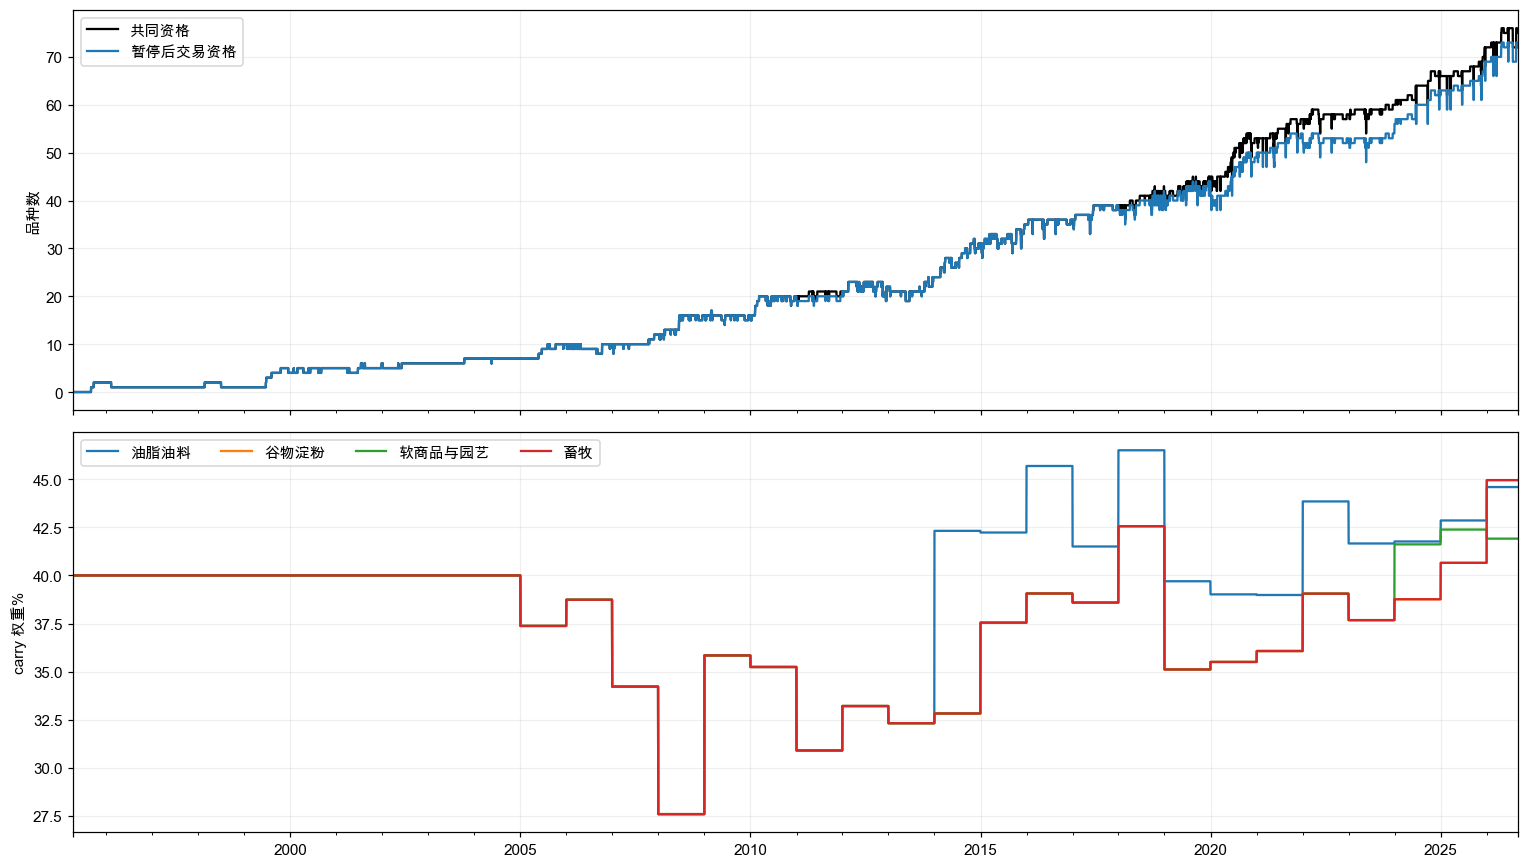

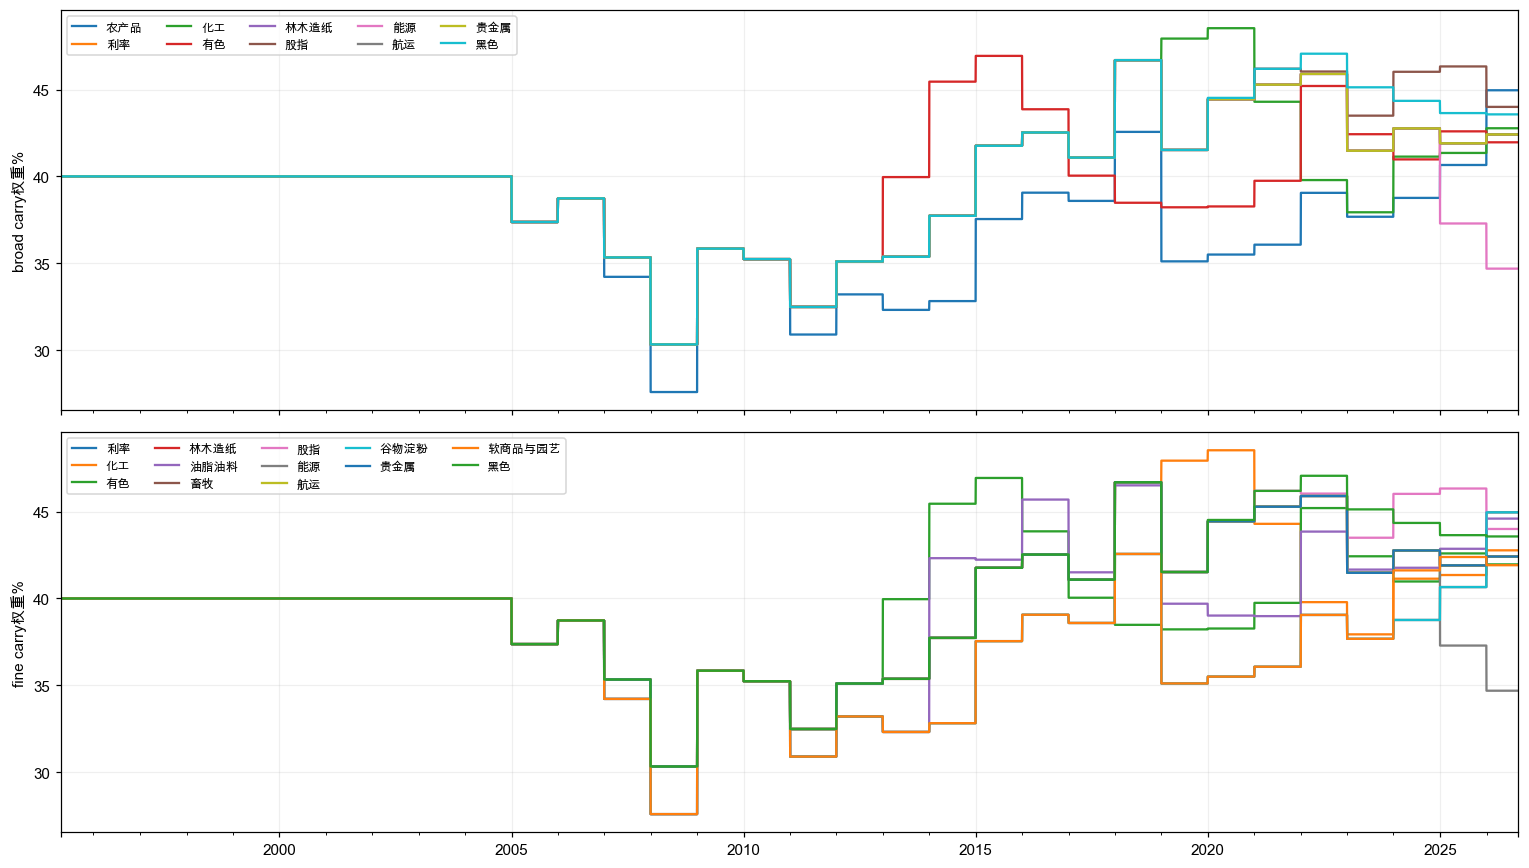

采用年度次数
level  source             
broad  broad:农产品        18
       broad:化工          8
       broad:有色         14
       broad:股指          6
       broad:能源          2
       broad:黑色          7
       global:全市场      165
       固定40%            90
fine   broad:农产品        56
       fine:化工           8
       fine:有色          14
       fine:油脂油料        13
       fine:股指           6
       fine:能源           2
       fine:软商品与园艺       3
       fine:黑色           7
       global:全市场      177
       固定40%           117
global global:全市场       22
       固定40%             9

In [33]:
# 固定资金反事实：暂停时原观察订单置零，恢复时重新跟随该订单；原生延迟、成本保持一致。
event_rows, pause_summary, pause_paths = [], [], {}
for observation, paused in pauses.items():
    if observation.startswith('prefix'):
        continue
    source = shadow if observation=='baseline' else pd.concat({
        'carry':pd.read_parquet(AUDIT_ROOT/'carry_diagnostics'/f'implemented_shadow_{observation}.parquet'),
        'breakout':shadow.xs('breakout')},names=['family']).sort_index()
    cfg = Config(deepcopy(BASE_CONFIG))
    with redirect_stdout(StringIO()):
        observer = System([Account(),ReportPortfolio(),ReportPositionSizing(),ReportRawData(),
            ForecastCombine(),ForecastScaleCap(),ReportRules()],ResearchData(),cfg)
        for code in eligible_codes:
            state = paused[code]
            for family in ['carry','breakout']:
                history = source.xs((family,code)).reindex(INDEX)
                counter = observer.accounts._pandl_for_instrument_with_cash_costs(
                    code,history.order.where(~state,0.),delayfill=True,roundpositions=True)
                path = pd.DataFrame({'baseline_net_cnh':history.net_cnh,
                    'paused_net_cnh':counter.as_ts.reindex(INDEX).fillna(0.),
                    'gross_change_cnh':counter.gross.as_ts.reindex(INDEX).fillna(0.)-history.gross_pct*CAPITAL/100,
                    'cost_change_cnh':counter.costs.as_ts.reindex(INDEX).fillna(0.)-history.cost_pct.fillna(0.)*CAPITAL/100})
                path['net_change_cnh'] = path.paused_net_cnh-path.baseline_net_cnh
                bad = history.shadow_equity.le(0) | (CAPITAL+path.paused_net_cnh.cumsum()).le(0) | ~np.isfinite(path).all(axis=1)
                failure = path.index[bad].min()
                path['normal'] = path.index<failure if pd.notna(failure) else True
                np.testing.assert_allclose(path.net_change_cnh,path.gross_change_cnh+path.cost_change_cnh,atol=1e-4)
                if not state.any():
                    np.testing.assert_allclose(path.net_change_cnh,0.,atol=1e-4)
                    continue
                pause_paths[(observation,family,code)] = path
                covered = pd.Series(False,index=INDEX)
                episodes = state.ne(state.shift(1).fillna(False)).cumsum()
                for _,episode in state.groupby(episodes):
                    if not episode.iloc[0]:
                        continue
                    start = episode.index.min()
                    ongoing = episode.index.max()==INDEX.max()
                    end = min(INDEX.max(),episode.index.max()+pd.offsets.BDay(2))
                    selected = (INDEX>=start)&(INDEX<=end)&path.normal
                    covered |= selected
                    block = path.loc[selected]
                    delta = block.net_change_cnh.sum() if len(block) else np.nan
                    event_rows.append(dict(observation=observation,instrument=code,family=family,
                        start=start,end=end,still_paused=ongoing,first_failure=failure,
                        gross_change_cnh=block.gross_change_cnh.sum(),cost_change_cnh=block.cost_change_cnh.sum(),
                        net_change_cnh=delta,net_gain_cnh=max(delta,0),net_loss_cnh=max(-delta,0)))
                total = path.loc[path.normal,'net_change_cnh'].sum()
                inside = path.loc[covered,'net_change_cnh'].sum()
                outside = path.loc[path.normal & ~covered,'net_change_cnh'].sum()
                np.testing.assert_allclose(inside+outside,total,atol=1e-5)
                pause_summary.append(dict(observation=observation,family=family,instrument=code,
                    first_failure=failure,total_change_cnh=total,event_change_cnh=inside,tail_change_cnh=outside))
        observer.data.data.close()
pause_events = pd.DataFrame(event_rows)
pause_events.to_csv(RUN_ROOT/'pause_events.csv',index=False)
pd.DataFrame(pause_summary).to_csv(RUN_ROOT/'pause_counterfactual_summary.csv',index=False)
pd.concat(pause_paths,names=['observation','family','instrument','date']).to_parquet(RUN_ROOT/'pause_counterfactual.parquet')
display(pause_events.query("observation=='baseline'").groupby('family')[['gross_change_cnh','cost_change_cnh','net_gain_cnh','net_loss_cnh']].sum()/10_000)
print('单位万元；逐事件拆分暂停净增益/净损失，两条路径共同止于首次账户失效前。')
print('退出/恢复费用进入事件窗口；事件外原生换月费用尾差与全期净差分别保存。')
fig,axes = plt.subplots(2,1,figsize=(14,8),sharex=True)
daily_n.plot(ax=axes[0],label='共同资格',color='black')
(daily_n-pauses['baseline'].where(eligibility,False).sum(axis=1)).plot(ax=axes[0],label='暂停后交易资格')
axes[0].set_ylabel('品种数');axes[0].legend()
for group in ['油脂油料','谷物淀粉','软商品与园艺','畜牧']:
    codes = classification.index[classification.fine.eq(group)].intersection(eligible_codes)
    (100*ratio_policies['baseline']['fine_annual'][codes].mean(axis=1)).plot(ax=axes[1],label=group)
axes[1].set_ylabel('carry 权重%');axes[1].legend(ncol=4);fig.tight_layout()
fig.savefig(RUN_ROOT/'figures/decisions_and_agriculture_weights.png');plt.show()
fig,axes = plt.subplots(2,1,figsize=(14,8),sharex=True)
for level,ax in zip(['broad','fine'],axes):
    table = ratio_policies['baseline'][level+'_annual']
    for group in sorted(classification.loc[eligible_codes,level].unique()):
        codes = classification.index[classification[level].eq(group)].intersection(eligible_codes)
        (100*table[codes].mean(axis=1)).plot(ax=ax,label=group)
    ax.set_ylabel(level+' carry权重%');ax.legend(ncol=5,fontsize=8)
fig.tight_layout();fig.savefig(RUN_ROOT/'figures/category_weights.png');plt.show()
display(category_scores.query("observation=='baseline'").groupby(['level','source']).size().to_frame('采用年度次数'))


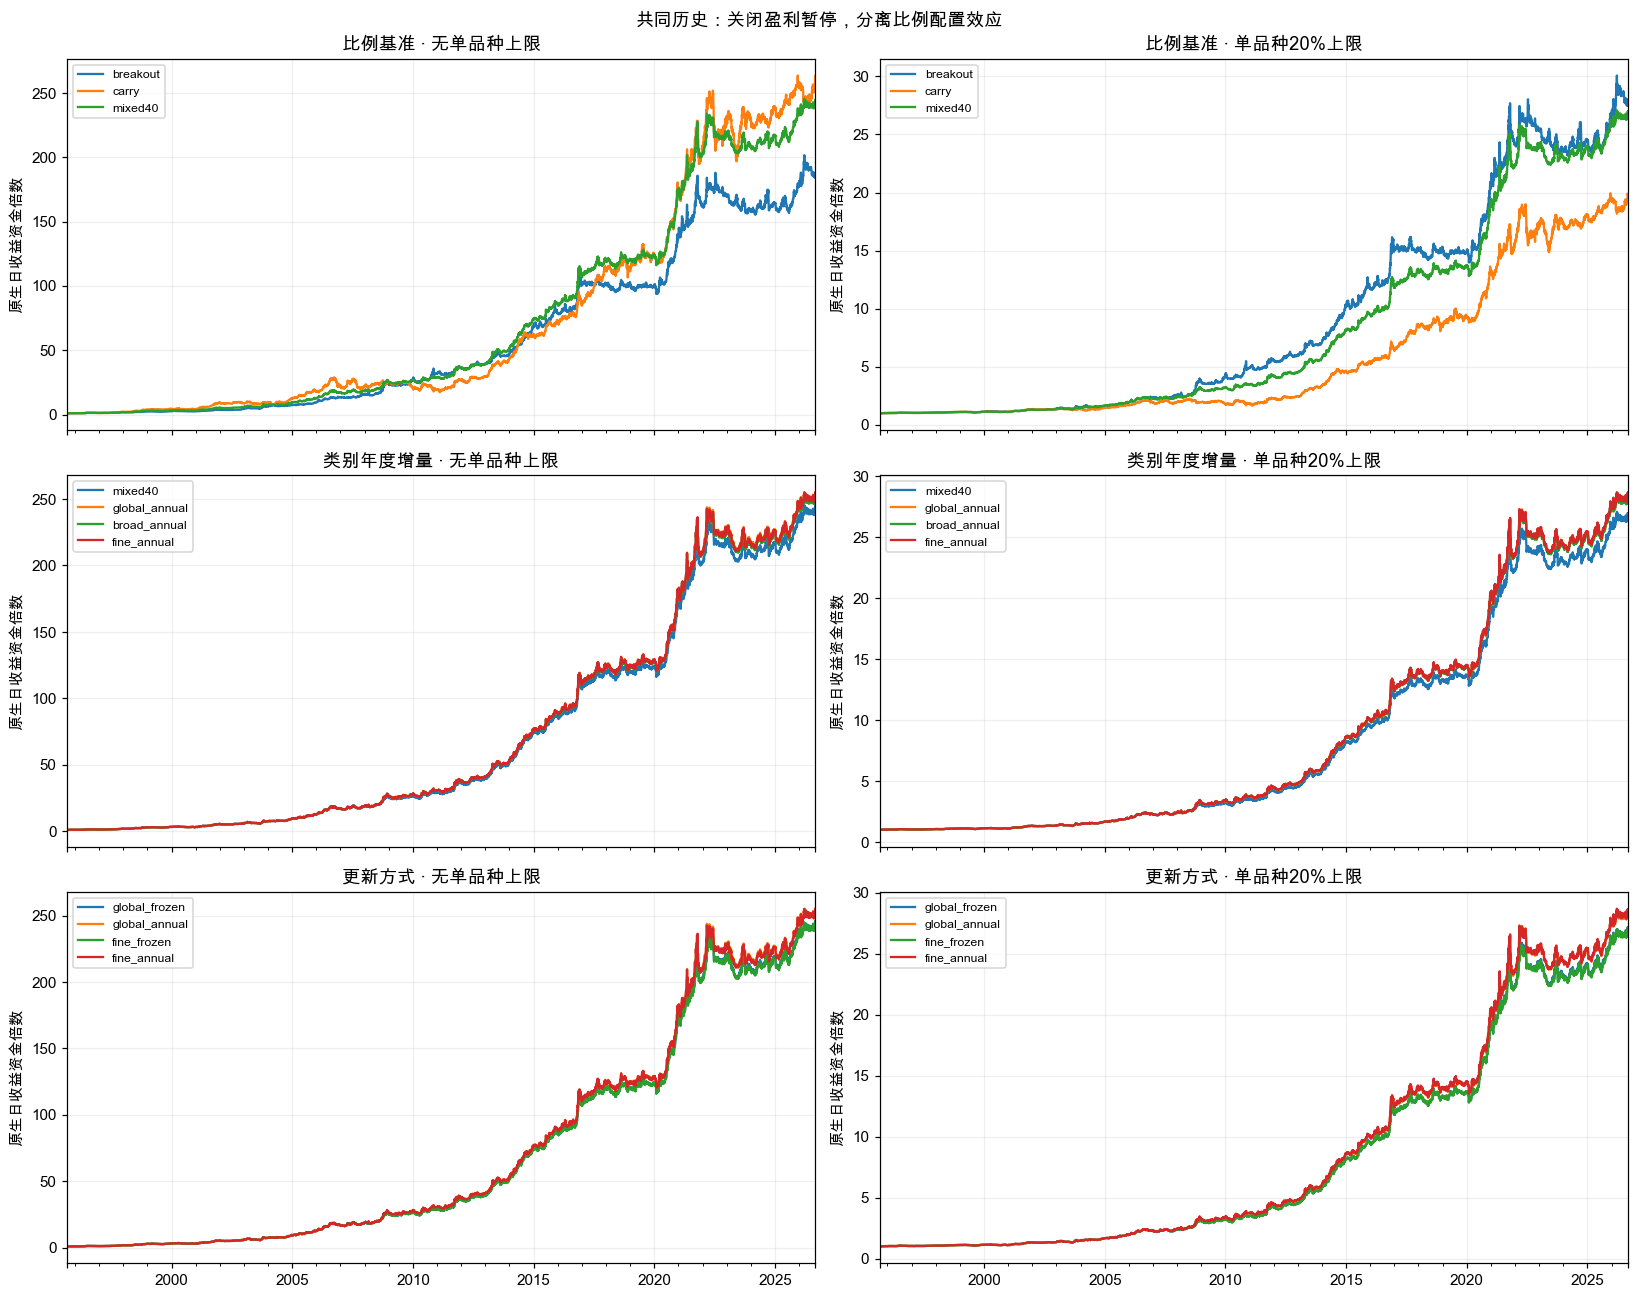

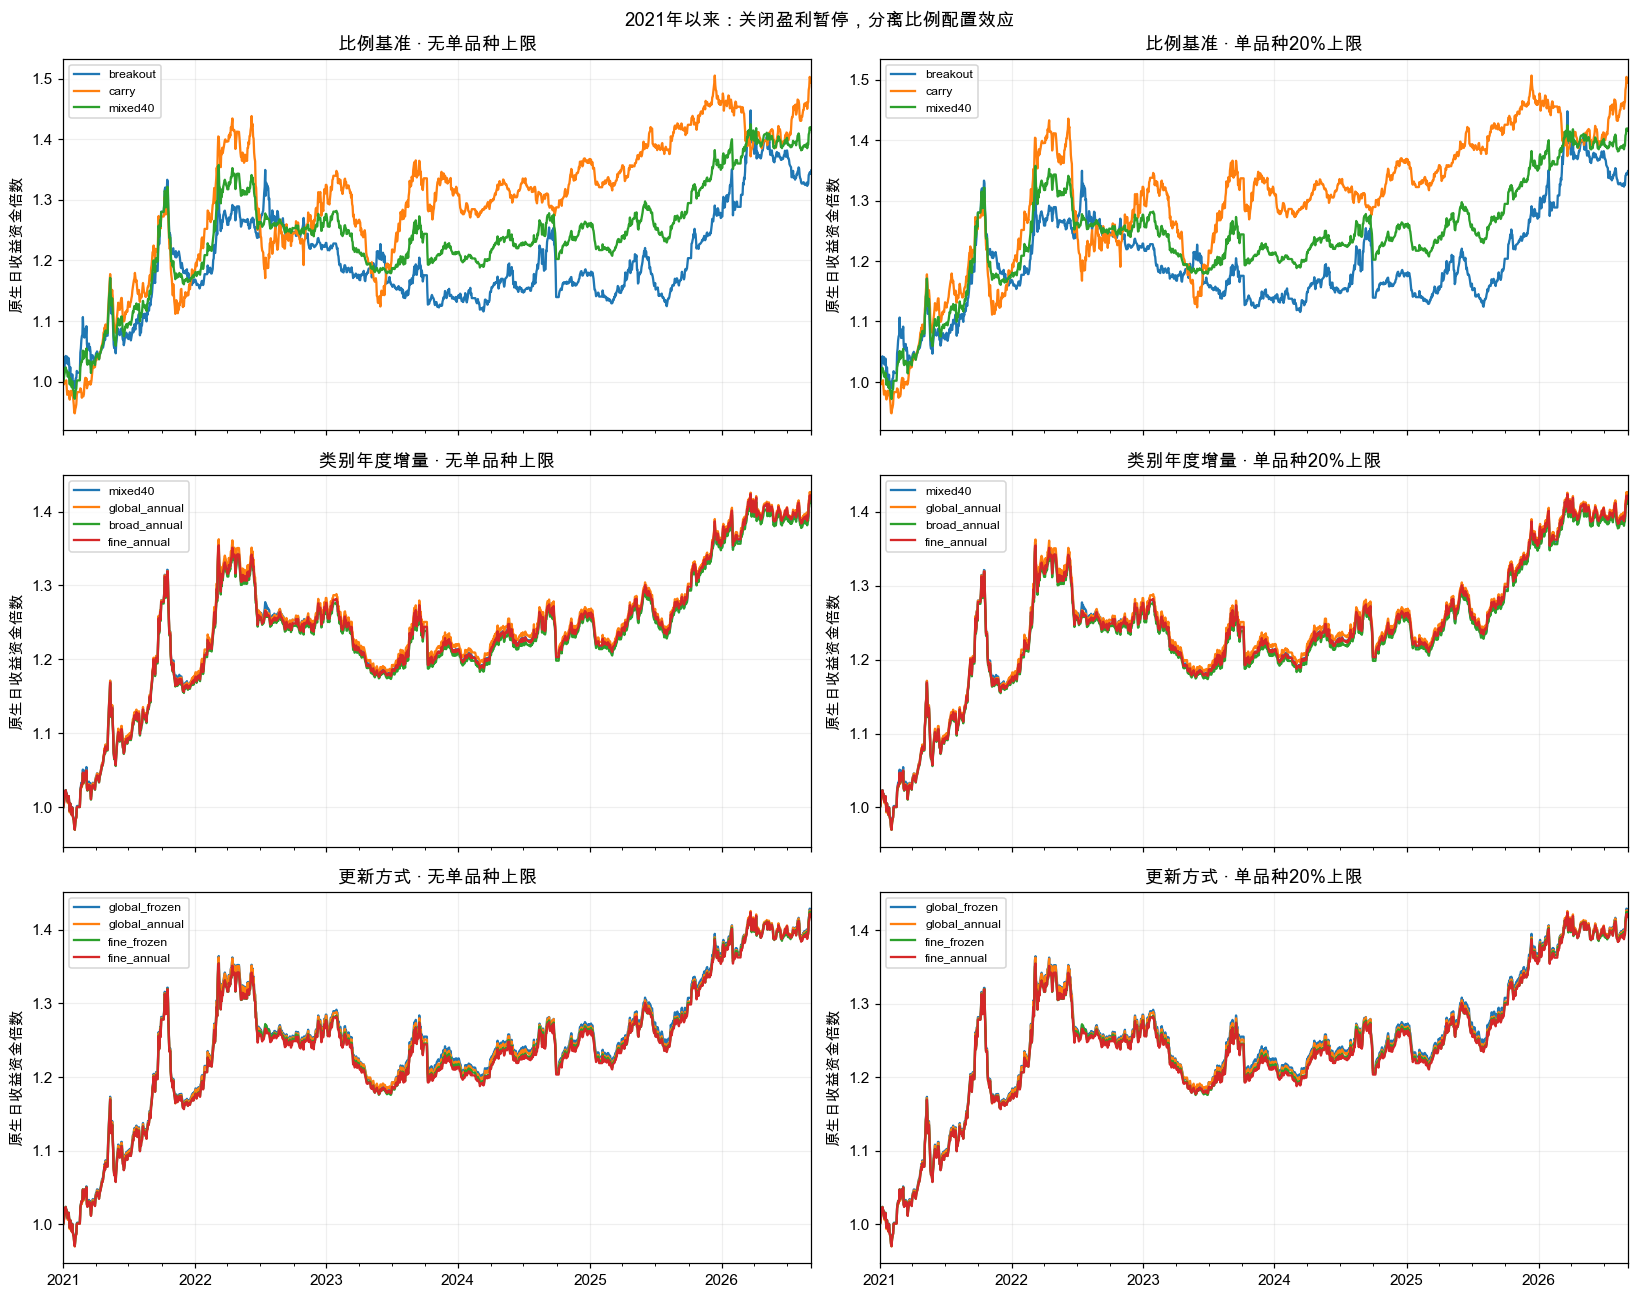

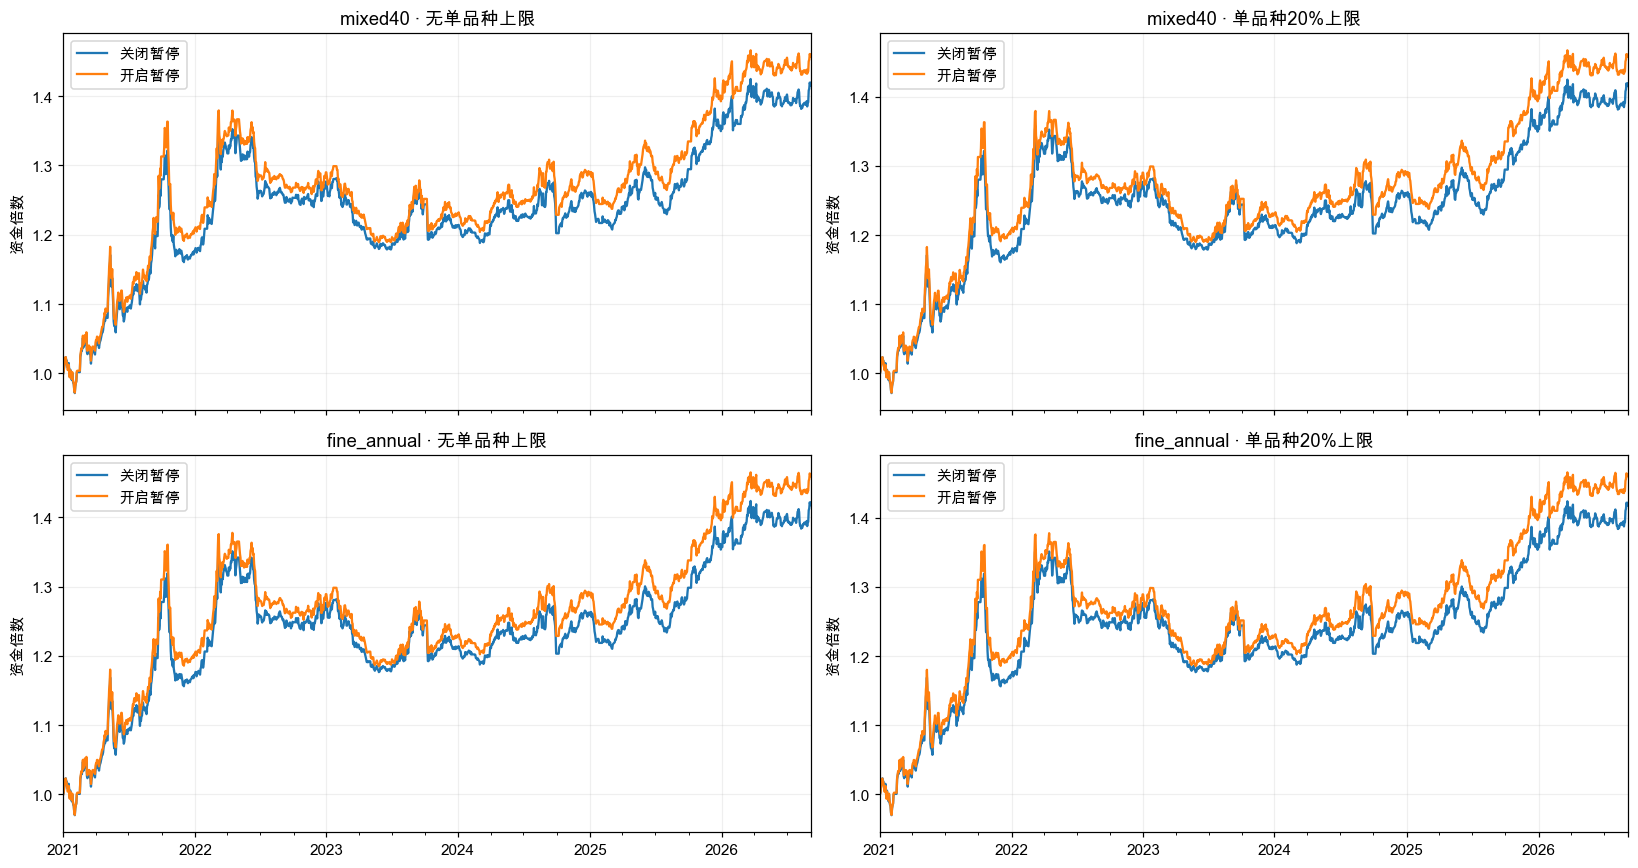

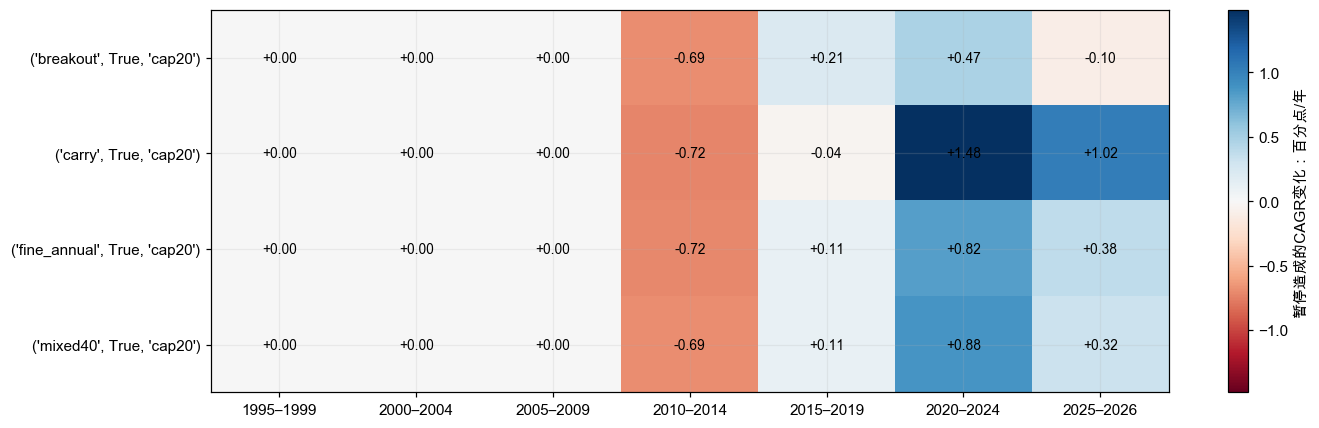

In [25]:
# 无上限与20%分别画；全部线性坐标，各图只比较对应问题。
groups = {
    '比例基准':['breakout','carry','mixed40'],
    '类别年度增量':['mixed40','global_annual','broad_annual','fine_annual'],
    '更新方式':['global_frozen','global_annual','fine_frozen','fine_annual']}
for period,start in [('共同历史',common_start),('2021年以来',pd.Timestamp('2021-01-01'))]:
    fig,axes = plt.subplots(3,2,figsize=(15,12),sharex=True)
    for row,(question,selected) in enumerate(groups.items()):
        for col,cap in enumerate(CAPS):
            ax = axes[row,col]
            for policy in selected:
                f = results[(policy,False,cap)].loc[start:common_end]
                ((1+f.net_pct/100).cumprod()).plot(ax=ax,label=policy)
            ax.set_title(question+' · '+CAP_LABELS[cap])
            ax.set_ylabel('原生日收益资金倍数');ax.legend(fontsize=8)
    fig.suptitle(period+'：关闭盈利暂停，分离比例配置效应')
    fig.tight_layout();fig.savefig(RUN_ROOT/f'figures/wealth_{period}.png');plt.show()
fig,axes = plt.subplots(2,2,figsize=(15,8),sharex=True)
for row,policy in enumerate(['mixed40','fine_annual']):
    for col,cap in enumerate(CAPS):
        ax = axes[row,col]
        for pause in [False,True]:
            f = results[(policy,pause,cap)].loc['2021':common_end]
            ((1+f.net_pct/100).cumprod()).plot(ax=ax,label='开启暂停' if pause else '关闭暂停')
        ax.set_title(policy+' · '+CAP_LABELS[cap]);ax.set_ylabel('资金倍数');ax.legend()
fig.tight_layout();fig.savefig(RUN_ROOT/'figures/pause_wealth_2021.png');plt.show()
heat = comparisons_table.query("question=='退出' and cap=='cap20'").copy()
heat = heat.loc[heat.period.str.match(r'^\d{4}–')]
pivot = heat.pivot(index='variant',columns='period',values='cagr_change_pp')
fig,ax = plt.subplots(figsize=(13,4))
bound = max(abs(pivot.to_numpy()).max(),.1)
im = ax.imshow(pivot,vmin=-bound,vmax=bound,cmap='RdBu',aspect='auto')
ax.set_xticks(range(len(pivot.columns)),pivot.columns);ax.set_yticks(range(len(pivot)),pivot.index)
for i in range(len(pivot)):
    for j in range(len(pivot.columns)):
        ax.text(j,i,f'{pivot.iloc[i,j]:+.2f}',ha='center',va='center',fontsize=9)
fig.colorbar(im,ax=ax,label='暂停造成的CAGR变化：百分点/年')
fig.tight_layout();fig.savefig(RUN_ROOT/'figures/pause_subperiods.png');plt.show()


## 敞口、换手与容量

实际敞口比值=延迟后的持仓绝对手数×未复权价格绝对值×合约乘数×汇率／原生实际资金。下单上限和延迟估值超限分别保存。表中 turnover 表示决策订单的名义换手，订单经过原生延迟成交。容量使用同持有合约此前20个真实交易日成交量，换月分别检查旧合约退出与新合约开仓。缺少、零成交量及无真实报价日的订单分别计数；这些日期上的原生日线成交依赖模拟填价假设。

收益贡献同时保存万元现金与每日组合资本归一化后的累计百分点，并逐期间与组合加总核对。1亿元的历史模拟对稀疏合约存在容量约束；固定成本模型没有按订单参与率增加冲击成本。

In [26]:
volume = pd.read_parquet(DATA_ROOT/'volume_diagnostics.parquet')
capacity_rows, contribution_rows, concentration_rows = [], [], []
for (policy,pause,cap), frame in results.items():
    label = f'{policy}_pause{int(pause)}_{cap}'
    wide = pd.read_parquet(RUN_ROOT/f'{label}_instruments.parquet')
    for code in eligible_codes:
        part = wide.xs(code)
        vol = volume.xs(code).reindex(part.index)
        prior = vol.contract_volume_prior_mean20
        chain = vol.price_contract.ffill()
        rolled = chain.ne(chain.shift(1)) & chain.notna() & chain.shift(1).notna()
        new_order = part.order.sub(part.held).abs().where(~rolled,part.order.abs())
        old_exit = part.held.abs().where(rolled,0.)
        new_ratio = new_order/prior.where(prior.gt(0))
        old_ratio = old_exit/prior.shift(1).where(prior.shift(1).gt(0))
        unknown_order = (new_order.gt(0)&prior.fillna(0).le(0)) | (old_exit.gt(0)&prior.shift(1).fillna(0).le(0))
        order_ratio = pd.concat([new_ratio,old_ratio],axis=1).max(axis=1).where(~unknown_order)
        holding_ratio = part.held.abs()/prior.where(prior.gt(0))
        observed = market[code].observed.reindex(part.index).fillna(False)
        tradable = observed & frame.normal.reindex(part.index).fillna(False)
        for period,(start,end) in {'完整历史':(part.index.min(),part.index.max()),**periods}.items():
            sample = part.loc[start:end].loc[lambda x:frame.normal.reindex(x.index).fillna(False)]
            contribution_rows.append(dict(policy=policy,pause=pause,cap=cap,period=period,instrument=code,
                cash_wan=sample.net_cnh.sum()/10_000,
                net_pp=(100*sample.net_cnh/frame.capital.reindex(sample.index)).sum(),
                cost_pp=(100*sample.cost_cnh/frame.capital.reindex(sample.index)).sum()))
            dates = part.index[(part.index>=start)&(part.index<=end)&tradable]
            held_days = part.held.reindex(dates).abs().gt(0)
            lev = part.leverage.reindex(dates).where(held_days).dropna()
            order_dates = part.index[(part.index>=start)&(part.index<=end)&frame.normal.reindex(part.index).fillna(False)]
            orders = order_ratio.reindex(order_dates).where((new_order+old_exit).reindex(order_dates).gt(0)).dropna()
            worst = lev.idxmax() if len(lev) else pd.NaT
            concentration_rows.append(dict(policy=policy,pause=pause,cap=cap,period=period,instrument=code,
                description=metadata.loc[code,'Description'],holding_share=held_days.mean(),
                leverage_median=lev.median(),leverage_p95=lev.quantile(.95),leverage_max=lev.max(),
                days_over_cap=int(lev.gt(.2).sum()) if cap=='cap20' else 0,worst_date=worst,
                worst_price=market[code].price.reindex(part.index).loc[worst] if pd.notna(worst) else np.nan,
                worst_position=part.held.loc[worst] if pd.notna(worst) else np.nan,
                worst_capital=frame.capital.reindex(part.index).loc[worst] if pd.notna(worst) else np.nan,
                worst_forecast=part.forecast.loc[worst] if pd.notna(worst) else np.nan,
                worst_vol=market[code].used_vol_pct.reindex(part.index).loc[worst] if pd.notna(worst) else np.nan,
                worst_idm=frame.idm.reindex(part.index).loc[worst] if pd.notna(worst) else np.nan))
            capacity_rows.append(dict(policy=policy,pause=pause,cap=cap,period=period,instrument=code,
                order_adv_p95=orders.quantile(.95),order_adv_max=orders.max(),
                holding_adv_p95=holding_ratio.reindex(dates).where(held_days).quantile(.95),
                orders_over_10pct=int(orders.gt(.1).sum()),
                missing_volume_orders=int(unknown_order.reindex(order_dates).sum()),
                orders_without_real_quote=int(((new_order+old_exit).gt(0)&~observed).reindex(order_dates).sum())))

    del wide
capacity_table = pd.DataFrame(capacity_rows)
concentration = pd.DataFrame(concentration_rows)
contribution = pd.DataFrame(contribution_rows)
for (policy,pause,cap,period), rows in contribution.groupby(['policy','pause','cap','period']):
    frame = results[(policy,pause,cap)]
    start,end = periods.get(period,(frame.index.min(),frame.index.max()))
    sample = frame.loc[start:end].loc[lambda x:x.normal]
    np.testing.assert_allclose(rows.net_pp.sum(),sample.net_pct.sum(),atol=1e-8)
    np.testing.assert_allclose(rows.cost_pp.sum(),sample.cost_pct.sum(),atol=1e-8)
capacity_table.to_csv(RUN_ROOT/'capacity.csv',index=False)
concentration.to_csv(RUN_ROOT/'concentration.csv',index=False)
contribution.to_csv(RUN_ROOT/'contribution.csv',index=False)
print('2021年以来20%上限的固定40%与细类年度＋暂停：实际估值超限与容量')
display(concentration.query("period=='2021年以来' and cap=='cap20' and policy in ['mixed40','fine_annual']").sort_values('leverage_max',ascending=False).head(12))
display(capacity_table.query("period=='2021年以来' and cap=='cap20' and policy=='fine_annual' and pause").sort_values('order_adv_p95',ascending=False).head(12))


2021年以来20%上限的固定40%与细类年度＋暂停：实际估值超限与容量


,policy,pause,cap,period,instrument,description,holding_share,leverage_median,leverage_p95,leverage_max,days_over_cap,worst_date,worst_price,worst_position,worst_capital,worst_forecast,worst_vol,worst_idm
28472,fine_annual,True,cap20,2021年以来,DCE_RR,大商所粳米,1.000,0.127,0.190,0.201,1,2022-08-16,"3,408.000","-15,328.000","2,594,668,210.839",-12.722,5.940,2.484
10472,mixed40,True,cap20,2021年以来,DCE_RR,大商所粳米,0.999,0.127,0.190,0.201,1,2022-08-16,"3,408.000","-14,433.000","2,445,185,908.969",-12.835,5.940,2.477
8672,mixed40,False,cap20,2021年以来,DCE_RR,大商所粳米,0.999,0.119,0.188,0.195,0,2024-03-21,"3,562.000","-12,604.000","2,307,947,789.503",-15.600,4.892,2.476
26672,fine_annual,False,cap20,2021年以来,DCE_RR,大商所粳米,1.000,0.118,0.187,0.193,0,2024-03-29,"3,565.000","-13,313.000","2,455,477,422.043",-13.393,4.582,2.477
9942,mixed40,True,cap20,2021年以来,CFFEX_TL,中金所三十年期国债,0.861,0.048,0.121,0.140,0,2024-08-05,112.970,296.000,"2,394,928,096.263",10.578,5.067,2.498
27942,fine_annual,True,cap20,2021年以来,CFFEX_TL,中金所三十年期国债,0.860,0.047,0.118,0.137,0,2024-08-05,112.970,309.000,"2,554,311,761.363",10.389,5.067,2.497
8142,mixed40,False,cap20,2021年以来,CFFEX_TL,中金所三十年期国债,0.861,0.046,0.113,0.131,0,2024-08-05,112.970,274.000,"2,366,238,657.701",10.578,5.067,2.495
26142,fine_annual,False,cap20,2021年以来,CFFEX_TL,中金所三十年期国债,0.860,0.045,0.110,0.128,0,2024-08-05,112.970,286.000,"2,518,921,123.652",10.389,5.067,2.495
28342,fine_annual,True,cap20,2021年以来,DCE_FB,大商所纤维板,0.861,0.033,0.074,0.122,0,2025-12-09,"1,248.000","-27,863.000","2,846,810,311.304",-16.013,8.851,2.499
10342,mixed40,True,cap20,2021年以来,DCE_FB,大商所纤维板,0.861,0.033,0.073,0.121,0,2025-12-09,"1,248.000","-25,884.000","2,663,923,063.976",-15.888,8.851,2.499


,policy,pause,cap,period,instrument,order_adv_p95,order_adv_max,holding_adv_p95,orders_over_10pct,missing_volume_orders,orders_without_real_quote
28342,fine_annual,True,cap20,2021年以来,DCE_FB,5.105,630.749,37.131,543,20,19
28472,fine_annual,True,cap20,2021年以来,DCE_RR,3.608,60.886,11.418,467,37,34
27982,fine_annual,True,cap20,2021年以来,CZCE_CY,0.183,21.850,1.553,66,28,26
28062,fine_annual,True,cap20,2021年以来,CZCE_PK,0.172,21.440,1.136,33,25,23
28602,fine_annual,True,cap20,2021年以来,SHFE_AD,0.158,2.567,0.677,3,0,0
28712,fine_annual,True,cap20,2021年以来,SHFE_OP,0.134,1.017,0.934,6,8,7
28272,fine_annual,True,cap20,2021年以来,DCE_B,0.127,15.561,2.036,47,48,48
28772,fine_annual,True,cap20,2021年以来,SHFE_SS,0.094,0.649,0.197,34,45,43
28542,fine_annual,True,cap20,2021年以来,GFEX_SI,0.061,6.995,0.523,12,12,11
28412,fine_annual,True,cap20,2021年以来,DCE_LG,0.049,0.848,0.537,7,11,11


## 跨时期稳定性与配对年度抽样

配对抽取相同年份，比较原生日收益CAGR差值，报告2.5%—97.5%分位区间。该区间描述已有年份重组的不确定性。2021年以来年度数量少，且训练窗口重叠；单次正收益不等于稳定有效。

In [27]:
# 预先固定2000次配对年度抽样；同一年两策略一起取样，保持年内日收益顺序。
rng = np.random.default_rng(20260907)
bootstrap_rows = []
for question, old_key,new_key in comparisons:
    if new_key not in results:
        continue
    for period,start in [('共同历史',common_start),('2021年以来',pd.Timestamp('2021-01-01'))]:
        pair = pd.concat({'old':results[old_key].net_pct,'new':results[new_key].net_pct},axis=1).loc[start:common_end]
        annual_log = np.log1p(pair/100).groupby(pair.index.year).sum()
        annual_days = pair.groupby(pair.index.year).size().reindex(annual_log.index).to_numpy()
        draws = rng.integers(0,len(annual_log),size=(2000,len(annual_log)))
        sampled_log = annual_log.to_numpy()[draws].sum(axis=1)
        sampled_years = annual_days[draws].sum(axis=1)/ANNUAL_DAYS
        sampled_cagr = 100*np.expm1(sampled_log/sampled_years[:,None])
        increment = sampled_cagr[:,1]-sampled_cagr[:,0]
        bootstrap_rows.append(dict(question=question,baseline=str(old_key),variant=str(new_key),
            period=period,years=len(annual_log),low=np.quantile(increment,.025),
            median=np.quantile(increment,.5),high=np.quantile(increment,.975),
            fraction_positive=np.mean(increment>0)))
bootstrap = pd.DataFrame(bootstrap_rows)
bootstrap.to_csv(RUN_ROOT/'paired_year_bootstrap.csv',index=False)
display(bootstrap.query("period=='2021年以来' and question in ['退出','Carry综合方案']"))
print('区间单位为CAGR变化百分点/年；2021年以来只有6个年度块，2026为未完整年。重叠训练与年份序列依赖限制了抽样解释。')


,question,baseline,variant,period,years,low,median,high,fraction_positive
1,退出,"('breakout', False, 'unlimited')","('breakout', True, 'unlimited')",2021年以来,6,-0.416,0.574,1.647,0.875
3,退出,"('breakout', False, 'cap20')","('breakout', True, 'cap20')",2021年以来,6,-0.422,0.575,1.501,0.856
5,退出,"('carry', False, 'unlimited')","('carry', True, 'unlimited')",2021年以来,6,-0.938,0.518,1.965,0.736
7,退出,"('carry', False, 'cap20')","('carry', True, 'cap20')",2021年以来,6,-0.896,0.512,1.956,0.767
9,退出,"('mixed40', False, 'unlimited')","('mixed40', True, 'unlimited')",2021年以来,6,-0.584,0.514,1.651,0.802
11,退出,"('mixed40', False, 'cap20')","('mixed40', True, 'cap20')",2021年以来,6,-0.575,0.519,1.655,0.814
13,退出,"('fine_annual', False, 'unlimited')","('fine_annual', True, 'unlimited')",2021年以来,6,-0.570,0.520,1.622,0.833
15,退出,"('fine_annual', False, 'cap20')","('fine_annual', True, 'cap20')",2021年以来,6,-0.575,0.537,1.637,0.833
81,Carry综合方案,"('fine_annual', True, 'unlimited')","('improved_annual_fine', True, 'unlimited')",2021年以来,6,-0.059,0.334,0.770,0.942
83,Carry综合方案,"('fine_annual', True, 'cap20')","('improved_annual_fine', True, 'cap20')",2021年以来,6,-0.080,0.323,0.771,0.948


区间单位为CAGR变化百分点/年；2021年以来只有6个年度块，2026为未完整年。重叠训练与年份序列依赖限制了抽样解释。


,mode,effective,instrument,action_baseline,action,carry_sr_baseline,carry_sr
0,annual,2023-01-02,DCE_CS,继续暂停,恢复,-0.444,-0.154
1,annual,2023-01-02,DCE_M,继续暂停,恢复,0.174,0.296
2,annual,2024-01-01,DCE_CS,继续暂停,继续交易,-0.305,-0.075
3,annual,2024-01-01,DCE_M,恢复,继续交易,0.281,0.359
4,annual,2025-01-01,DCE_CS,继续暂停,继续交易,-0.701,-0.433
5,annual,2026-01-01,DCE_CS,继续暂停,暂停,-0.652,-0.126
6,frozen,2023-01-02,DCE_CS,继续暂停,恢复,-0.444,-0.169
7,frozen,2023-01-02,DCE_M,继续暂停,恢复,0.174,0.273
8,frozen,2024-01-01,DCE_CS,继续暂停,继续交易,-0.305,-0.112
9,frozen,2024-01-01,DCE_M,恢复,继续交易,0.281,0.348


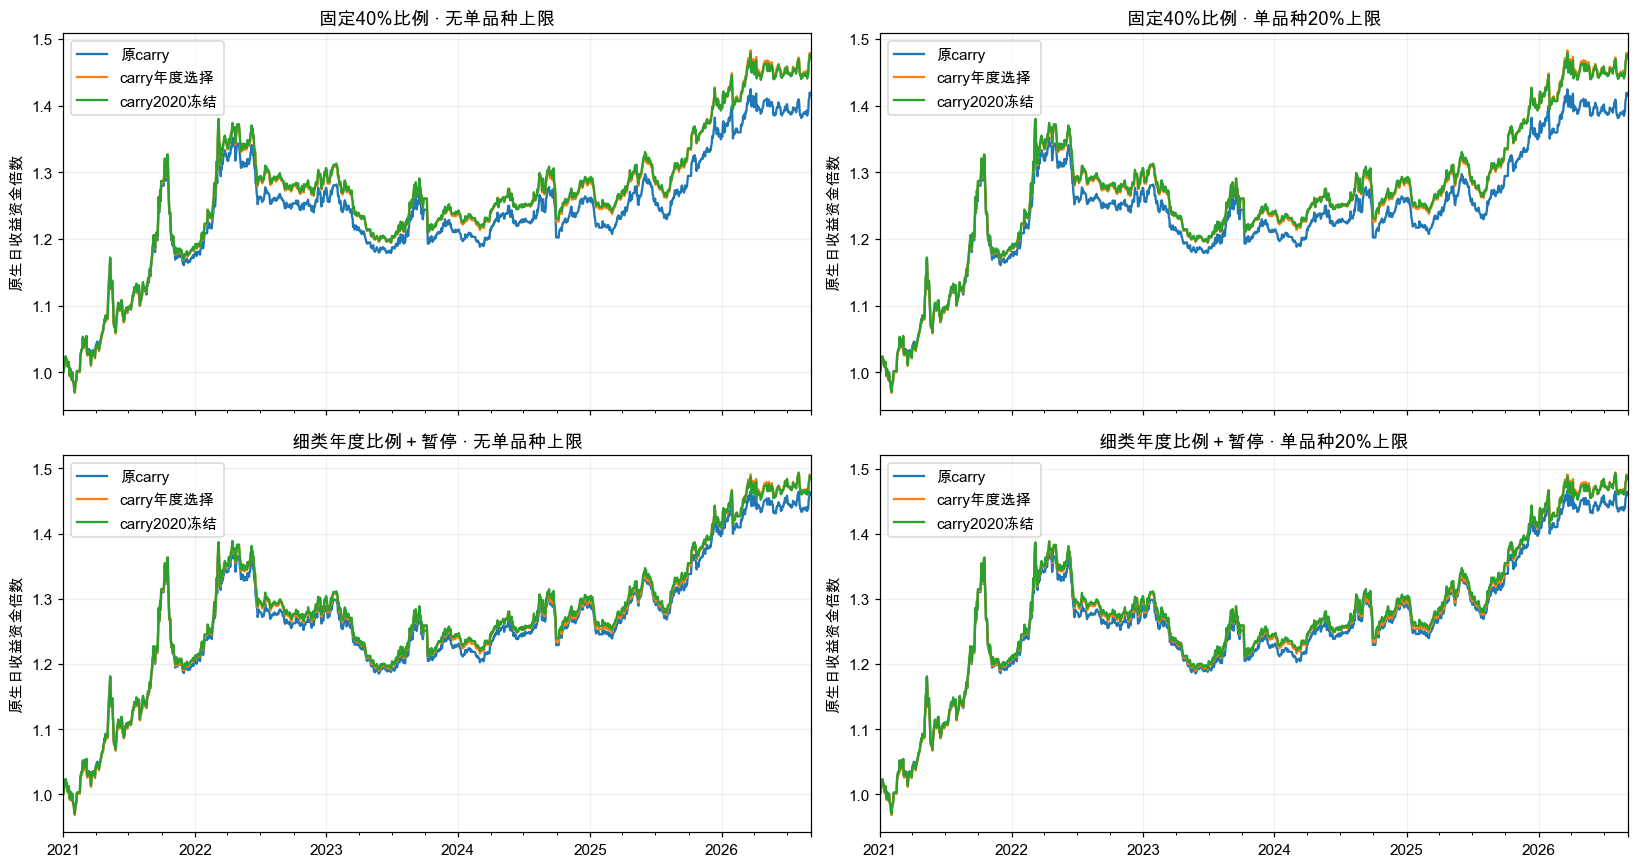

同一组合环境对比：Carry候选采用后的收益与费用、类别和暂停反馈均由原生持仓重新计算。


In [28]:
# 综合版本必须使用实际实施carry的观察收益重新评分；保留改变了的名单。
base_decisions = decisions.query("observation=='baseline'").set_index(['review','instrument'])
changed_rows = []
for mode in ['annual','frozen']:
    candidate = decisions.query('observation==@mode').set_index(['review','instrument'])
    joined = candidate.join(base_decisions[['paused','action','carry_net','carry_sr']],rsuffix='_baseline')
    changed = joined.loc[joined.paused.ne(joined.paused_baseline) | joined.action.ne(joined.action_baseline)].copy()
    changed['mode'] = mode
    changed_rows.append(changed.reset_index())
decision_changes = pd.concat(changed_rows,ignore_index=True)
decision_changes.to_csv(RUN_ROOT/'improved_decision_changes.csv',index=False)
display(decision_changes[['mode','effective','instrument','action_baseline','action','carry_sr_baseline','carry_sr']])
fig,axes = plt.subplots(2,2,figsize=(15,8),sharex=True)
for row,(base_policy,pause,context) in enumerate([('mixed40',False,'mixed40'),('fine_annual',True,'fine')]):
    for col,cap in enumerate(CAPS):
        ax = axes[row,col]
        for policy,label in [(base_policy,'原carry'),('improved_annual_'+context,'carry年度选择'),('improved_frozen_'+context,'carry2020冻结')]:
            if (policy,pause,cap) in results:
                f = results[(policy,pause,cap)].loc['2021':common_end]
                ((1+f.net_pct/100).cumprod()).plot(ax=ax,label=label)
        ax.set_title(('固定40%比例' if row==0 else '细类年度比例＋暂停')+' · '+CAP_LABELS[cap])
        ax.set_ylabel('原生日收益资金倍数');ax.legend()
fig.tight_layout();fig.savefig(RUN_ROOT/'figures/improved_carry_2021.png');plt.show()
print('同一组合环境对比：Carry候选采用后的收益与费用、类别和暂停反馈均由原生持仓重新计算。')


## 验证

年度决策使用分别截断到2020和2023的观察数据重新生成并逐项对比。原始价格另截断重建波动率与7条规则。组合核对延迟、整手、暂停空仓、费用与现金盈亏加总；独立系统进一步检查IDM和决策路径。

In [29]:
import json
assert len(coverage)==95 and len(eligible_codes)==90
assert classification.index.nunique()==95 and classification.groupby('fine').broad.nunique().eq(1).all()
assert BASE_CONFIG['volatility_calculation']['backfill'] is False
assert all(f.index.max()<=CUTOFF for f in results.values())
assert all(hashlib.sha256(Path(p).read_bytes()).hexdigest()==h for p,h in input_hashes.items())
assert decisions.loc[decisions.valid_days.lt(756),'usable'].eq(False).all()
assert decisions.loc[~decisions.enough_history,'usable'].eq(False).all()
assert decisions.loc[decisions.usable,['carry_traded','breakout_traded']].all().all()
for code in eligible_codes:
    for _,segment in market[code].groupby('window'):
        assert pd.isna(segment.returns.iloc[0])
        assert raw_rule_frames[code].loc[segment.index].iloc[:19].breakout40.isna().all()
for code,cut in [('SHFE_RB','2019-12-31'),('DCE_FB','2023-06-30'),('CZCE_LR','2018-10-17')]:
    stop = pd.Timestamp(cut)+pd.Timedelta(days=1)-pd.Timedelta(nanoseconds=1)
    for _,window in trading_windows.loc[trading_windows.Instrument.eq(code)].iterrows():
        if window.Start>stop:
            continue
        cfg = Config(deepcopy(BASE_CONFIG))
        cfg.instruments,cfg.trading_rules = [code],deepcopy(RULES)
        prefix = System([WindowRawData(),Rules()],ResearchData(windows=pd.DataFrame([window]),end=stop),cfg)
        vol = prefix.rawdata.daily_returns_volatility(code)
        pd.testing.assert_series_equal(vol,market[code].used_vol_points.reindex(vol.index),check_names=False)
        for rule in RULES:
            actual = prefix.rules.get_raw_forecast(code,rule)
            pd.testing.assert_series_equal(actual,raw_rule_frames[code][rule].reindex(actual.index),check_names=False)
        prefix.data.data.close()
for observation,policies_by_mode in ratio_policies.items():
    for name,ratio in policies_by_mode.items():
        assert ratio.min().min()>=.2 and ratio.max().max()<=.7
        assert ratio.diff().abs().max().max()<=.100000001
        if name.endswith('frozen'):
            assert ratio.loc[:'2020'].eq(.4).all().all()
            assert ratio.loc['2021':].nunique().eq(1).all()
for (policy,pause,cap),frame in results.items():
    label = f'{policy}_pause{int(pause)}_{cap}'
    w = pd.read_parquet(RUN_ROOT/f'{label}_weights.parquet')
    ratio = pd.read_parquet(RUN_ROOT/f'{label}_carry_weights.parquet')
    assert np.allclose((ratio/4)*4+((1-ratio)/3)*3,1)
    assert np.allclose(w.sum(axis=1).loc[w.sum(axis=1).gt(0)],1)
    assert frame.gross_leverage.loc[frame.n_eligible.shift(1).fillna(0).eq(0)].eq(0).all()
# 原生buffer：零资格、单品种、多空、少于一手，以及收紧限额强制退出旧仓。
from systems.accounts.account_buffering_subsystem import apply_buffer
dates = pd.bdate_range('2020-01-01',periods=5)
target = pd.Series([10.,10.,-10.,-.2,0.],index=dates)
limit = pd.Series([3.,2.,1.,0.,0.],index=dates)
bounds = pd.DataFrame({'top_pos':target+5,'bot_pos':target-5}).clip(lower=-limit,upper=limit,axis=0)
buffered = apply_buffer(target.clip(-limit,limit),bounds,trade_to_edge=True,roundpositions=True)
assert buffered.abs().le(limit).all() and buffered.iloc[-2:].eq(0).all()
probe = pd.Series([-10.,10.],index=dates[:2])
native = accountCurve(pandlCalculationWithoutPositions(probe,probe*0,100.),is_percentage=True)
pd.testing.assert_series_equal(native.as_ts,probe,check_names=False,check_freq=False)
wealth = (1+native.as_ts/100).cumprod()
assert np.isclose((wealth/wealth.cummax().clip(lower=1)-1).min(),-.10)
print('规则/波动率截断、年度决策截断、首日收益、预算、buffer与静态输入检查完成。')


规则/波动率截断、年度决策截断、首日收益、预算、buffer与静态输入检查完成。


In [30]:
# 用截断输入建立全新组合；不把人工截断日当作审核终点提前平仓。
prefix_rows = []
for cut in ['2020-01-08','2023-06-30']:
    stop = pd.Timestamp(cut)+pd.Timedelta(days=1)-pd.Timedelta(nanoseconds=1)
    spec = policies[('fine_annual',True)]
    cfg = Config(deepcopy(BASE_CONFIG))
    cfg.dated_weights = (eligibility & ~spec['paused']).loc[:stop].astype(float)
    cfg.dated_weights = cfg.dated_weights.div(cfg.dated_weights.sum(axis=1).replace(0,np.nan),axis=0).fillna(0.)
    cfg.base_eligibility = eligibility.loc[:stop].copy()
    cfg.carry_proportion = spec['ratio'].loc[:stop].copy()
    cfg.forecast_weights = {name:1/7 for name in RULES}
    cfg.reference_idm,cfg.exposure_cap = None,None
    with redirect_stdout(StringIO()):
        prefix = System([Account(),ReportPortfolio(),AdaptivePositionSizing(),ReportRawData(),
            AdaptiveForecastCombine(),ForecastScaleCap(),ReportRules()],ResearchData(end=stop),cfg)
        curve = prefix.accounts.portfolio_with_multiplier(delayfill=True,roundpositions=True)
        old = results[('fine_annual',True,'unlimited')]
        # 原生周末虚拟换月费用归入周五：末尾未完成业务日bin单列，不当作过去模型修订。
        compare_dates = curve.as_ts.index[curve.as_ts.index<=pd.Timestamp(cut)-pd.offsets.BDay(2)]
        np.testing.assert_allclose(curve.percent.as_ts.reindex(compare_dates),old.net_pct.reindex(compare_dates),equal_nan=True,atol=1e-9)
        idm = prefix.portfolio.get_instrument_diversification_multiplier()
        common = idm.index.intersection(compare_dates)
        np.testing.assert_allclose(idm.loc[common],old.idm.reindex(common),equal_nan=True,atol=1e-10)
        for code in ['SHFE_RB','DCE_C','SHFE_CU','DCE_FB']:
            held = prefix.accounts.pandl_for_instrument_with_multiplier(code,delayfill=True,roundpositions=True).pandl_calculator_with_costs.positions
            previous = pd.read_parquet(RUN_ROOT/'fine_annual_pause1_unlimited_instruments.parquet').xs(code)
            held = held.reindex(INDEX).ffill().fillna(0.)
            common = held.index.intersection(compare_dates)
            np.testing.assert_allclose(held.loc[common],previous.held.reindex(common),equal_nan=True)
        prefix_rows.append({'cutoff':cut,'compared_days':len(compare_dates),
            'max_net_error':(curve.percent.as_ts.reindex(compare_dates)-old.net_pct.reindex(compare_dates)).abs().max(),
            'end_bin_difference':(curve.percent.as_ts-old.net_pct.reindex(curve.percent.as_ts.index)).tail(2).abs().max()})
        prefix.data.data.close()
    del prefix
    gc.collect()
prefix_checks = pd.DataFrame(prefix_rows)
prefix_checks.to_csv(RUN_ROOT/'native_prefix_checks.csv',index=False)
display(prefix_checks)
receipt = {'cutoff':AS_OF,'capital_cnh':CAPITAL,'target_vol_pct':VOL_TARGET,
    'portfolio_systems':len(results),'baseline_shadow_accounts':180,
    'account_failures':int(pd.DataFrame(run_rows).failure.notna().sum()),
    'all_histories':95,'eligible_histories':90,'native_annual_days':ANNUAL_DAYS,
    'baseline_reproduced':len(reconciliation),'native_prefix_cases':len(prefix_checks),
    'signals_yearly_decisions_and_weights_prefix':'passed','native_pnl_cost_delay_round_caps':'passed',
    'inputs_unchanged':True}
(RUN_ROOT/'validation.json').write_text(json.dumps(receipt,ensure_ascii=False,indent=2))
display(pd.Series(receipt).to_frame('结果'))


,cutoff,compared_days,max_net_error,end_bin_difference
0,2020-01-08,6451,0.000,0.000
1,2023-06-30,7358,0.000,0.006


,结果
cutoff,2026-09-07
capital_cnh,"100,000,000.000"
target_vol_pct,16.000
portfolio_systems,44
baseline_shadow_accounts,180
account_failures,0
all_histories,95
eligible_histories,90
native_annual_days,256.000
baseline_reproduced,6


In [37]:
# 最终验收收据：原生路径、反事实、贡献与配套诊断共同核对。
diagnostic_validation = pd.read_csv(AUDIT_ROOT/'carry_diagnostics'/'validation.csv')
assert diagnostic_validation.passed.all()
assert len(results)==44 and len(statistics)==440
assert len(reconciliation)==6 and not pd.DataFrame(run_rows).failure.notna().any()
assert prefix_checks.max_net_error.max()<1e-9
assert len(coverage)==95 and len(eligible_codes)==90
receipt.update({'model_signature':model_signature,'configuration_and_source_saved':True,
    'contribution_period_reconciliation':True,'pause_counterfactual_native_costs':True,
    'pause_counterfactual_tail_reconciliation':True,'carry_candidate_accounts':1260,
    'carry_candidate_prefix_cases':144,'all_histories_with_figures':95})
(RUN_ROOT/'validation.json').write_text(json.dumps(receipt,ensure_ascii=False,indent=2))
display(pd.Series(receipt).to_frame('验收结果'))


,验收结果
cutoff,2026-09-07
capital_cnh,"100,000,000.000"
target_vol_pct,16.000
portfolio_systems,44
baseline_shadow_accounts,180
account_failures,0
all_histories,95
eligible_histories,90
native_annual_days,256.000
baseline_reproduced,6


In [36]:
lines = ['## 结果与适用边界','',
    '本轮证据支持在现有breakout中加入40%carry作为分散配置。固定比例已经提供明显的收益与回撤改善；亏损暂停、细分类别比例和年度更新的额外优势仍有限。农业carry季节调整在固定比例环境中提供了更清楚的增益，综合配置环境中的增益区间仍跨零。']
table = statistics.query("period=='2021年以来'").set_index(['policy','pause','cap'])
for cap in CAPS:
    b = table.loc[('breakout',False,cap)]
    m = table.loc[('mixed40',False,cap)]
    p = table.loc[('mixed40',True,cap)]
    g = table.loc[('global_annual',True,cap)]
    f = table.loc[('fine_annual',True,cap)]
    z = table.loc[('fine_frozen',True,cap)]
    lines.append(f"**{CAP_LABELS[cap]}，2021年以来：** 固定40%carry的CAGR为{m.cagr:.2f}%，纯breakout为{b.cagr:.2f}%，变化{m.cagr-b.cagr:+.2f}个百分点/年；对应净Sharpe为{m.sharpe:.2f}/{b.sharpe:.2f}，最大回撤为{m.max_dd:.2f}%/{b.max_dd:.2f}%。")
    lines.append(f"固定40%比例开启暂停后，CAGR变化{p.cagr-m.cagr:+.2f}个百分点/年，最大回撤变化{p.max_dd-m.max_dd:+.2f}个百分点。细类年度比例＋暂停相对全市场年度比例＋暂停，CAGR变化{f.cagr-g.cagr:+.2f}个百分点/年，净Sharpe变化{f.sharpe-g.sharpe:+.2f}。细类年度版相对冻结版，CAGR变化{f.cagr-z.cagr:+.2f}个百分点/年。")
    for mode in ['annual','frozen']:
        key = ('improved_'+mode+'_fine',True,cap)
        if key in table.index:
            improved = table.loc[key]
            lines.append(f"Carry候选{mode}综合版相对原carry细类年度＋暂停，CAGR变化{improved.cagr-f.cagr:+.2f}个百分点/年，净Sharpe变化{improved.sharpe-f.sharpe:+.2f}，最大回撤变化{improved.max_dd-f.max_dd:+.2f}个百分点。")
    lines.append('')
events = decisions.query("observation=='baseline'")
lines.append(f"原carry观察路径产生{events.action.eq('暂停').sum()}次暂停、{events.action.eq('恢复').sum()}次恢复。完整名单与两家族评分见年度决策表；恢复记录支持持续观察曾经亏损的品种。{len(shadow_failures)}个固定资金观察账户出现首次失效，失效后的数据不参与正常评分。")
for question in ['退出','类别增量','年度更新','Carry方案','Carry综合方案']:
    blocks = comparisons_table.loc[comparisons_table.question.eq(question)&comparisons_table.period.str.match(r'^\d{4}–')]
    if len(blocks):
        lines.append(f"{question}的固定五年分段比较：{blocks.cagr_change_pp.gt(1e-8).sum()}项改善、{blocks.cagr_change_pp.lt(-1e-8).sum()}项下降、{blocks.cagr_change_pp.abs().le(1e-8).sum()}项持平。未开始使用该方案的历史仍显示在表中。")
intervals = pd.read_csv(RUN_ROOT/'paired_year_bootstrap.csv')
lines += ['', '20%上限、2021年以来，固定40%比例采用年度carry选择后CAGR为6.98%，原carry为6.23%，变化+0.75个百分点/年；净Sharpe从0.758升至0.833，最大回撤从13.16%升至13.33%。按年度配对抽样的CAGR增量95%区间为[0.28,1.25]个百分点/年。冻结方案CAGR为6.95%，结果接近。',
    '固定40%比例的亏损暂停增量约+0.53个百分点/年，但抽样区间为[-0.57,1.66]；细类年度比例＋暂停相对全市场年度比例＋暂停为-0.03个百分点/年，未显示额外优势。原carry固定资金反事实的全期暂停净差在两家族均为负，提示错过恢复盈利的机会成本。',
    '季节调整加上细类年度比例和暂停，CAGR为7.11%，相对原carry同环境为+0.32个百分点/年，抽样区间[-0.08,0.77]跨零。复杂环节的收益不能简单相加。上述区间来自6个年度块、2000次抽样，2026年不完整；抽样没有重新选择模型。',
    '农业各细类的观察账户收益和Sharpe差异见配套carry诊断报告：油脂油料、谷物淀粉、软商品与园艺、畜牧分别列示。类别权重图与组合贡献只能提供辅助解释。',
    '参数没有按本轮收益再调优。类别比例需要先通过全市场比例对照；暂停效果需要同时看错过盈利与避开损失。Carry候选的原因证据、季节覆盖和验证失败记录见配套诊断报告。',
    '原生IDM与信号抵消使实际波动率随方案变化，16%是共同风险目标。CAGR与最大回撤由同一条原生净日收益计算；资金乘数和现金权益单列核对。',
    '本研究是在固定事后审核历史内按当时信息决策。2021年以来已被研究者查看，属于时间切分检验。短历史、已失效观察账户和季节样本不足都有单独记录；容量表中的高参与率合约需要额外评估成交冲击。']
conclusion_text = '\n\n'.join(lines)
(RUN_ROOT/'conclusions.md').write_text(conclusion_text)
display(Markdown(conclusion_text))


## 结果与适用边界



本轮证据支持在现有breakout中加入40%carry作为分散配置。固定比例已经提供明显的收益与回撤改善；亏损暂停、细分类别比例和年度更新的额外优势仍有限。农业carry季节调整在固定比例环境中提供了更清楚的增益，综合配置环境中的增益区间仍跨零。

**无单品种上限，2021年以来：** 固定40%carry的CAGR为6.23%，纯breakout为5.30%，变化+0.93个百分点/年；对应净Sharpe为0.76/0.54，最大回撤为13.16%/17.30%。

固定40%比例开启暂停后，CAGR变化+0.51个百分点/年，最大回撤变化+0.62个百分点。细类年度比例＋暂停相对全市场年度比例＋暂停，CAGR变化-0.03个百分点/年，净Sharpe变化-0.01。细类年度版相对冻结版，CAGR变化-0.01个百分点/年。

Carry候选annual综合版相对原carry细类年度＋暂停，CAGR变化+0.33个百分点/年，净Sharpe变化+0.03，最大回撤变化+0.27个百分点。

Carry候选frozen综合版相对原carry细类年度＋暂停，CAGR变化+0.31个百分点/年，净Sharpe变化+0.03，最大回撤变化+0.21个百分点。



**单品种20%上限，2021年以来：** 固定40%carry的CAGR为6.23%，纯breakout为5.30%，变化+0.93个百分点/年；对应净Sharpe为0.76/0.54，最大回撤为13.16%/17.31%。

固定40%比例开启暂停后，CAGR变化+0.53个百分点/年，最大回撤变化+0.57个百分点。细类年度比例＋暂停相对全市场年度比例＋暂停，CAGR变化-0.03个百分点/年，净Sharpe变化-0.01。细类年度版相对冻结版，CAGR变化-0.00个百分点/年。

Carry候选annual综合版相对原carry细类年度＋暂停，CAGR变化+0.32个百分点/年，净Sharpe变化+0.03，最大回撤变化+0.27个百分点。

Carry候选frozen综合版相对原carry细类年度＋暂停，CAGR变化+0.30个百分点/年，净Sharpe变化+0.03，最大回撤变化+0.21个百分点。



原carry观察路径产生10次暂停、7次恢复。完整名单与两家族评分见年度决策表；恢复记录支持持续观察曾经亏损的品种。5个固定资金观察账户出现首次失效，失效后的数据不参与正常评分。

退出的固定五年分段比较：20项改善、12项下降、24项持平。未开始使用该方案的历史仍显示在表中。

类别增量的固定五年分段比较：30项改善、26项下降、56项持平。未开始使用该方案的历史仍显示在表中。

年度更新的固定五年分段比较：38项改善、22项下降、24项持平。未开始使用该方案的历史仍显示在表中。

Carry方案的固定五年分段比较：14项改善、0项下降、14项持平。未开始使用该方案的历史仍显示在表中。

Carry综合方案的固定五年分段比较：14项改善、0项下降、14项持平。未开始使用该方案的历史仍显示在表中。



20%上限、2021年以来，固定40%比例采用年度carry选择后CAGR为6.98%，原carry为6.23%，变化+0.75个百分点/年；净Sharpe从0.758升至0.833，最大回撤从13.16%升至13.33%。按年度配对抽样的CAGR增量95%区间为[0.28,1.25]个百分点/年。冻结方案CAGR为6.95%，结果接近。

固定40%比例的亏损暂停增量约+0.53个百分点/年，但抽样区间为[-0.57,1.66]；细类年度比例＋暂停相对全市场年度比例＋暂停为-0.03个百分点/年，未显示额外优势。原carry固定资金反事实的全期暂停净差在两家族均为负，提示错过恢复盈利的机会成本。

季节调整加上细类年度比例和暂停，CAGR为7.11%，相对原carry同环境为+0.32个百分点/年，抽样区间[-0.08,0.77]跨零。复杂环节的收益不能简单相加。上述区间来自6个年度块、2000次抽样，2026年不完整；抽样没有重新选择模型。

农业各细类的观察账户收益和Sharpe差异见配套carry诊断报告：油脂油料、谷物淀粉、软商品与园艺、畜牧分别列示。类别权重图与组合贡献只能提供辅助解释。

参数没有按本轮收益再调优。类别比例需要先通过全市场比例对照；暂停效果需要同时看错过盈利与避开损失。Carry候选的原因证据、季节覆盖和验证失败记录见配套诊断报告。

原生IDM与信号抵消使实际波动率随方案变化，16%是共同风险目标。CAGR与最大回撤由同一条原生净日收益计算；资金乘数和现金权益单列核对。

本研究是在固定事后审核历史内按当时信息决策。2021年以来已被研究者查看，属于时间切分检验。短历史、已失效观察账户和季节样本不足都有单独记录；容量表中的高参与率合约需要额外评估成交冲击。